# Navigating the UK Property Market
### Predictive Analysis of House Price Index Trends with Affordability Modelling and Explainable Deep Learning

**Jerusha Johanna Janetrin Julies David Dass** · Student ID 25867550
MSc Data Science · Masters Project (6G7V0007)

---

House prices climbing doesn't automatically mean housing is *less* affordable  if wages climb just as
fast, nothing has really changed for a buyer. That gap between price and pay is what this project sets
out to model. Instead of forecasting price alone, it predicts an **affordability ratio** (regional house
price index ÷ regional median wage) the number that actually decides whether an ordinary worker can
buy a home.

The central question this notebook works through: can a **multi-task LSTM** that learns to predict
regional house prices *and* affordability at the same time  using wage growth as an extra signal
forecast more accurately, and explain itself more clearly, than the traditional workhorses (ARIMA,
SARIMA) and a single-task LSTM? And once the best model is found, **SHAP** is used to open it up and
ask *which* economic forces  interest rates, inflation, wages  are really driving affordability in
each region.

The sections below walk through the full pipeline: from merging four UK-government datasets, through
stationarity testing and feature engineering, to the competing models, a rigorous evaluation
(RMSE / MAE / MAPE, Diebold-Mariano significance testing, and a rolling backtest), and finally the
SHAP interpretability layer.

---

## 1. Load Merged Dataset

In [1]:
import os
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seeds fixed (SEED =", SEED, ") for reproducible results.")

Random seeds fixed (SEED = 42 ) for reproducible results.


In [2]:
import pandas as pd

df = pd.read_csv('/content/master_dataset.csv', parse_dates=['Date'])

In [3]:
print("Shape:", df.shape)

Shape: (1560, 9)


In [4]:
print("Date range:", df['Date'].min(), "→", df['Date'].max())

Date range: 2000-06-01 00:00:00 → 2026-05-01 00:00:00


In [5]:
print("Regions:", df['Region'].nunique())

Regions: 5


In [6]:
print(df['Region'].unique())

['London' 'North West' 'South East' 'Wales' 'Yorkshire and The Humber']


In [7]:
print("Columns:", list(df.columns))

Columns: ['Date', 'HPI', 'SalesVolume', 'Region', 'Year', 'MedianAnnualPay', 'CPI', 'BaseRate', 'AffordabilityRatio']


In [8]:
df.head()

,Date,HPI,SalesVolume,Region,Year,MedianAnnualPay,CPI,BaseRate,AffordabilityRatio
0,2000-06-01,26.9,14270.0,London,2000,24204.0,72.9,6.0,1.111387
1,2000-07-01,27.4,13278.0,London,2000,24204.0,72.5,6.0,1.132044
2,2000-08-01,27.6,12690.0,London,2000,24204.0,72.5,6.0,1.140307
3,2000-09-01,27.6,11521.0,London,2000,24204.0,73.1,6.0,1.140307
4,2000-10-01,27.3,11068.0,London,2000,24204.0,73.1,6.0,1.127913


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                1560 non-null   datetime64[ns]
 1   HPI                 1560 non-null   float64       
 2   SalesVolume         1550 non-null   float64       
 3   Region              1560 non-null   object        
 4   Year                1560 non-null   int64         
 5   MedianAnnualPay     1560 non-null   float64       
 6   CPI                 1560 non-null   float64       
 7   BaseRate            1560 non-null   float64       
 8   AffordabilityRatio  1560 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 109.8+ KB


In [10]:
df.describe()

,Date,HPI,SalesVolume,Year,MedianAnnualPay,CPI,BaseRate,AffordabilityRatio
count,1560,1560.000000,1550.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000
mean,2013-05-16 21:50:46.153846272,68.591667,8594.402581,2012.916667,28128.927564,98.169551,2.439423,2.433684
min,2000-06-01 00:00:00,25.100000,1172.000000,2000.000000,17157.000000,72.500000,0.100000,1.110450
25%,2006-11-23 12:00:00,56.075000,5299.000000,2006.000000,23740.000000,80.750000,0.500000,2.070101
50%,2013-05-16 12:00:00,65.950000,7897.500000,2013.000000,26892.000000,98.300000,0.750000,2.564675
75%,2019-11-08 12:00:00,85.600000,11213.000000,2019.000000,32813.000000,108.500000,4.500000,2.822431
max,2026-05-01 00:00:00,111.100000,33565.000000,2026.000000,49692.000000,142.400000,6.000000,3.406470
std,NaN,21.300460,4322.579674,7.518596,6622.412860,19.335437,2.136359,0.528530


In [11]:
numeric_house = df.select_dtypes(include=['int64', 'float64']).columns
categorical_house = df.select_dtypes(include=['object', 'bool']).columns

print("Numeric Columns:", numeric_house)
print("Categorical Columns:", categorical_house)

Numeric Columns: Index(['HPI', 'SalesVolume', 'Year', 'MedianAnnualPay', 'CPI', 'BaseRate',
       'AffordabilityRatio'],
      dtype='object')
Categorical Columns: Index(['Region'], dtype='object')


##**1b — Exploratory Data Analysis (structure, targets over time, correlation heatmap)**

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Structure + missingness
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "None")

Missing values per column:
SalesVolume    10
dtype: int64


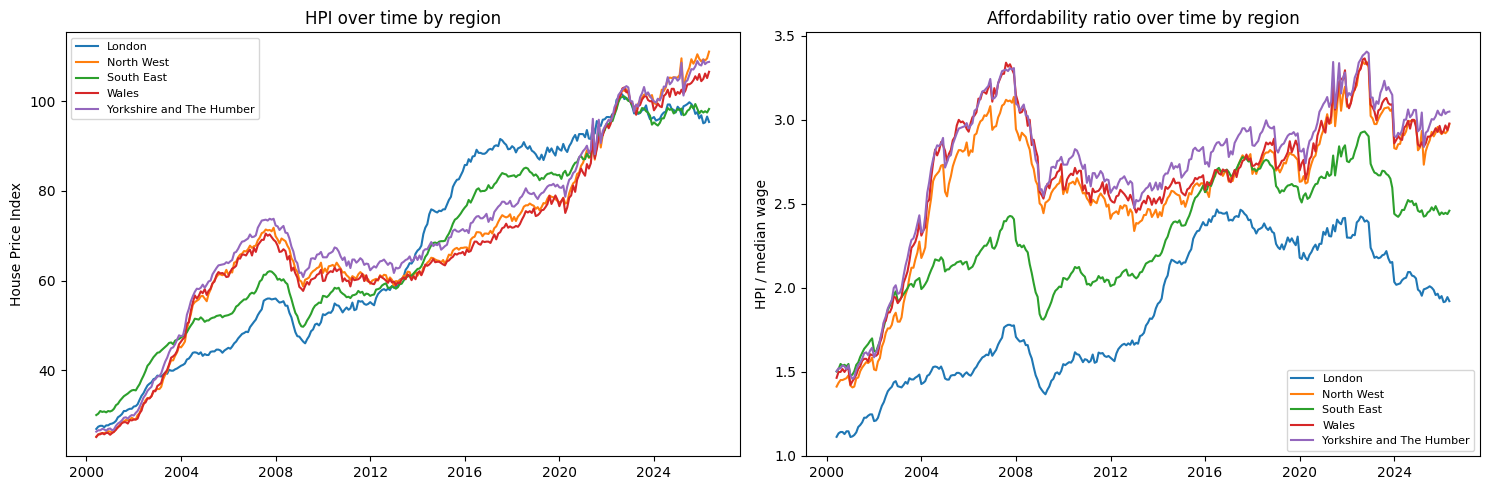

In [13]:
#2) Both targets over time, by region
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for region in df['Region'].unique():
    sub = df[df['Region'] == region].sort_values('Date')
    axes[0].plot(sub['Date'], sub['HPI'], label=region)
    axes[1].plot(sub['Date'], sub['AffordabilityRatio'], label=region)
axes[0].set_title("HPI over time by region"); axes[0].set_ylabel("House Price Index")
axes[1].set_title("Affordability ratio over time by region"); axes[1].set_ylabel("HPI / median wage")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

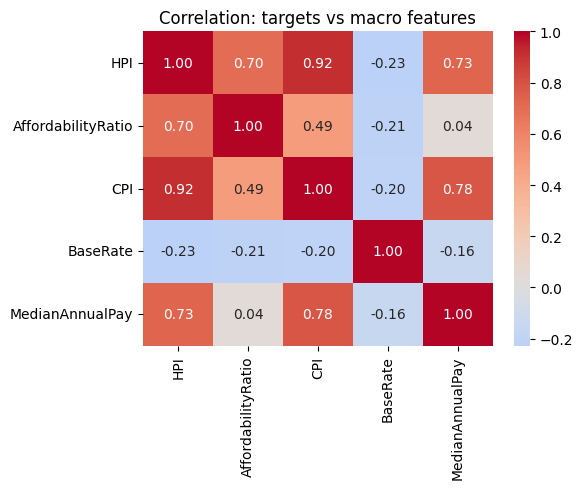

In [14]:
# 3) How do macro features relate to the targets?
macro = ['HPI', 'AffordabilityRatio', 'CPI', 'BaseRate', 'MedianAnnualPay']
plt.figure(figsize=(6, 5))
sns.heatmap(df[macro].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation: targets vs macro features")
plt.tight_layout(); plt.show()

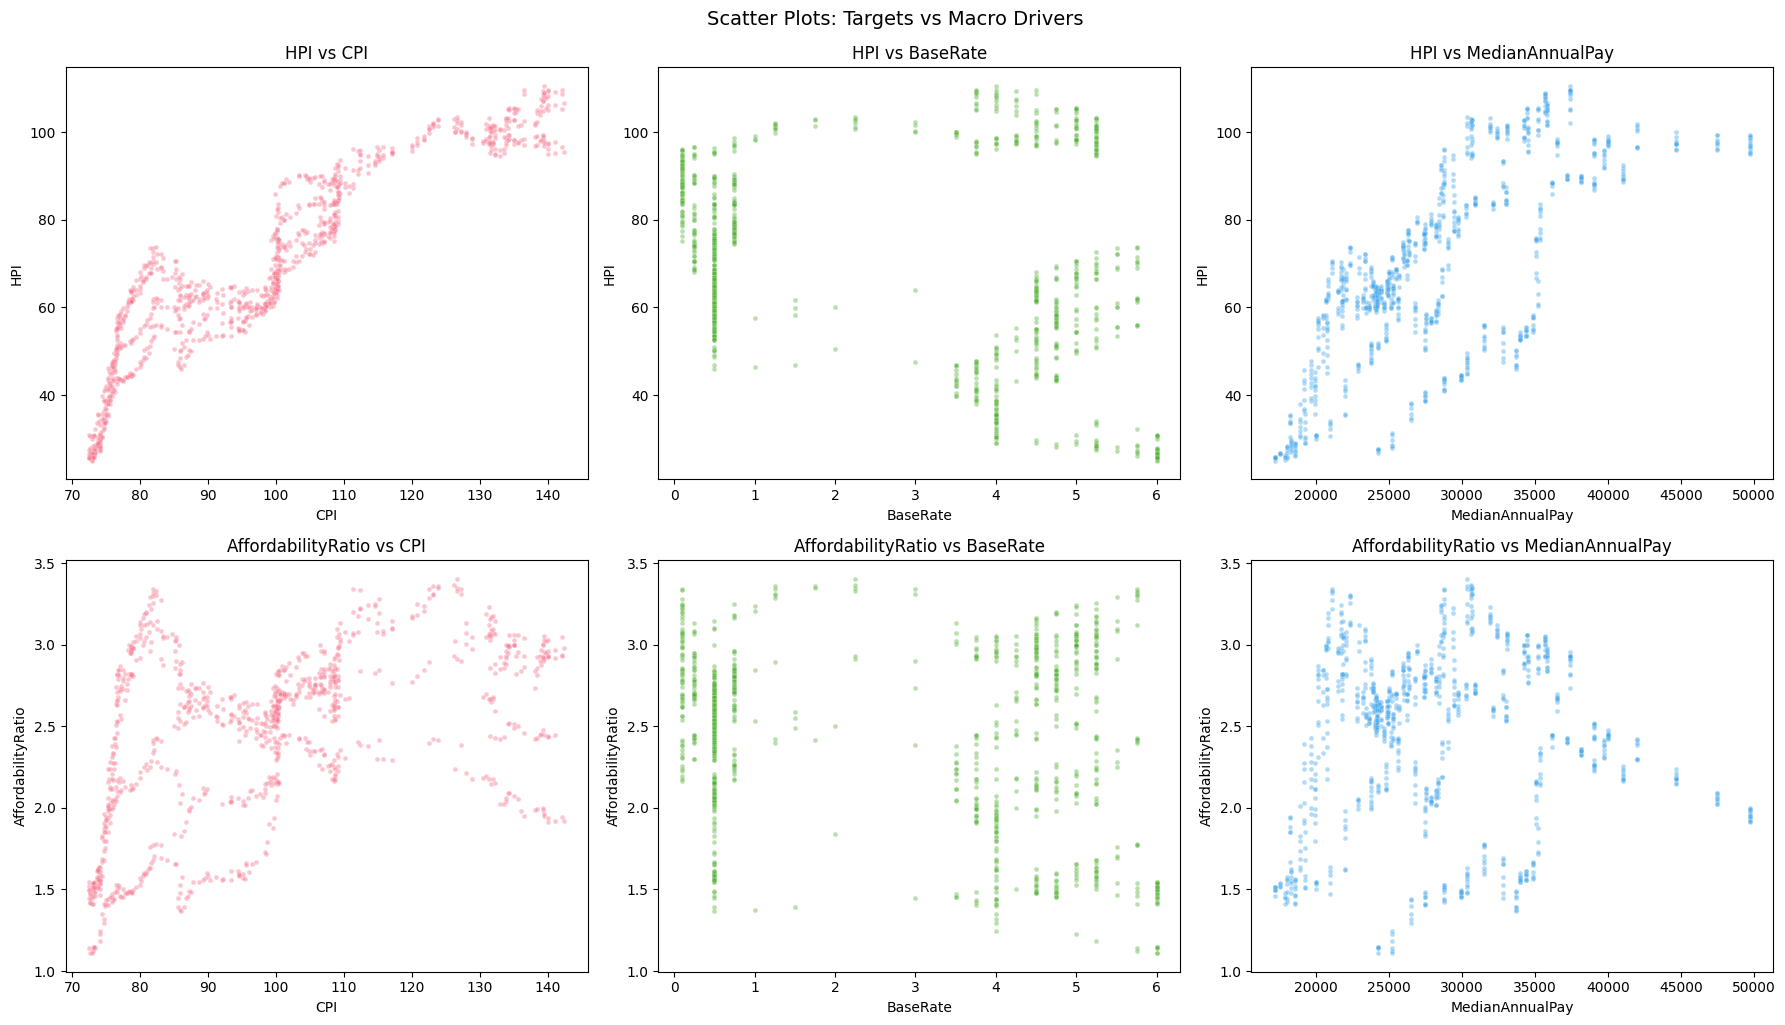

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Your macro drivers vs your two targets — the relationships that matter for YOUR question
features = ['CPI', 'BaseRate', 'MedianAnnualPay']
targets  = ['HPI', 'AffordabilityRatio']

# Optional: sample if the panel gets too dense to read
plot_df = df.sample(1000, random_state=42) if df.shape[0] > 1000 else df.copy()

cols = 3
rows = len(targets)                       # one row per target
fig, axs = plt.subplots(rows, cols, figsize=(18, 5 * rows))

for r, target in enumerate(targets):
    for c, feat in enumerate(features):
        sns.scatterplot(data=plot_df, x=feat, y=target, ax=axs[r, c],
                        s=12, alpha=0.4,
                        color=sns.color_palette("husl", len(features))[c])
        axs[r, c].set_title(f'{target} vs {feat}')
        axs[r, c].set_xlabel(feat)
        axs[r, c].set_ylabel(target)

plt.tight_layout()
plt.suptitle("Scatter Plots: Targets vs Macro Drivers", y=1.02, fontsize=14)
plt.show()

In [16]:
print(df.columns.tolist())

['Date', 'HPI', 'SalesVolume', 'Region', 'Year', 'MedianAnnualPay', 'CPI', 'BaseRate', 'AffordabilityRatio']


##1c — Missing Data & Noise Handling

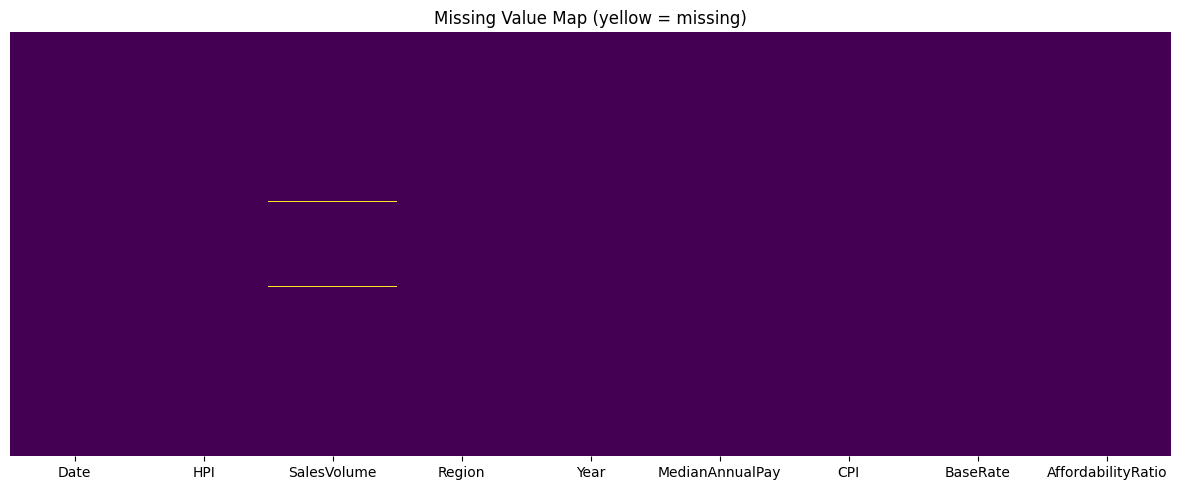

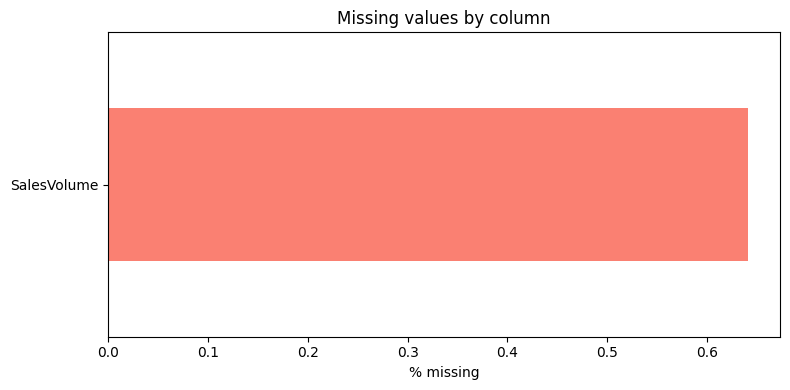

In [17]:
# Missing Visulaize
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Value Map (yellow = missing)")
plt.tight_layout()
plt.show()

# Bar chart of missing % per column (only if any exist)
miss = (df.isnull().sum() / len(df) * 100)
miss = miss[miss > 0].sort_values(ascending=False)
if len(miss):
    miss.plot(kind='barh', figsize=(8, 4), color='salmon')
    plt.xlabel("% missing"); plt.title("Missing values by column")
    plt.tight_layout(); plt.show()
else:
    print("No missing values — merged panel is complete.")

In [18]:
# Time series → interpolate within each region, then fill any edges
df = df.sort_values(['Region', 'Date']).reset_index(drop=True)

target_cols = ['HPI', 'AffordabilityRatio', 'CPI', 'BaseRate', 'MedianAnnualPay']
for col in target_cols:
    if col in df.columns:
        df[col] = df.groupby('Region')[col].transform(
            lambda s: s.interpolate(method='linear').ffill().bfill()
        )

print("Missing after handling:", df[target_cols].isnull().sum().sum())

Missing after handling: 0


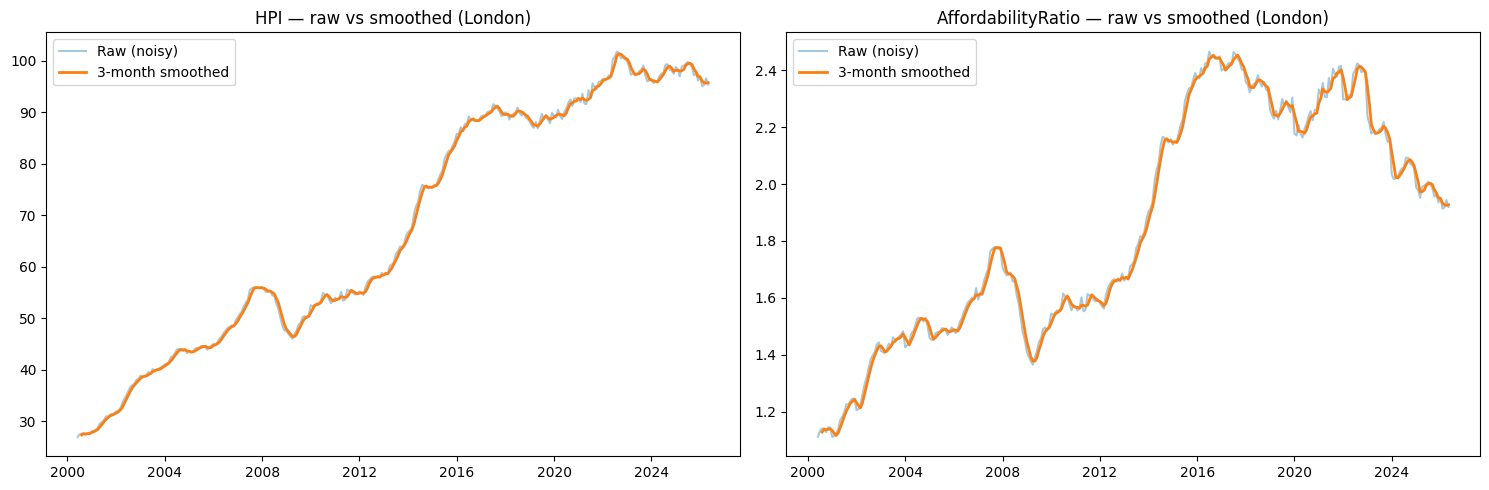

In [19]:
#visualize noise

# Noise = short-term wobble around the trend. Show it with a 3-month rolling mean.
region = df['Region'].unique()[0]      # example region
sub = df[df['Region'] == region].sort_values('Date')

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for i, target in enumerate(['HPI', 'AffordabilityRatio']):
    ax[i].plot(sub['Date'], sub[target], alpha=0.4, label='Raw (noisy)')
    ax[i].plot(sub['Date'], sub[target].rolling(3).mean(), linewidth=2, label='3-month smoothed')
    ax[i].set_title(f"{target} — raw vs smoothed ({region})")
    ax[i].legend()
plt.tight_layout()
plt.show()

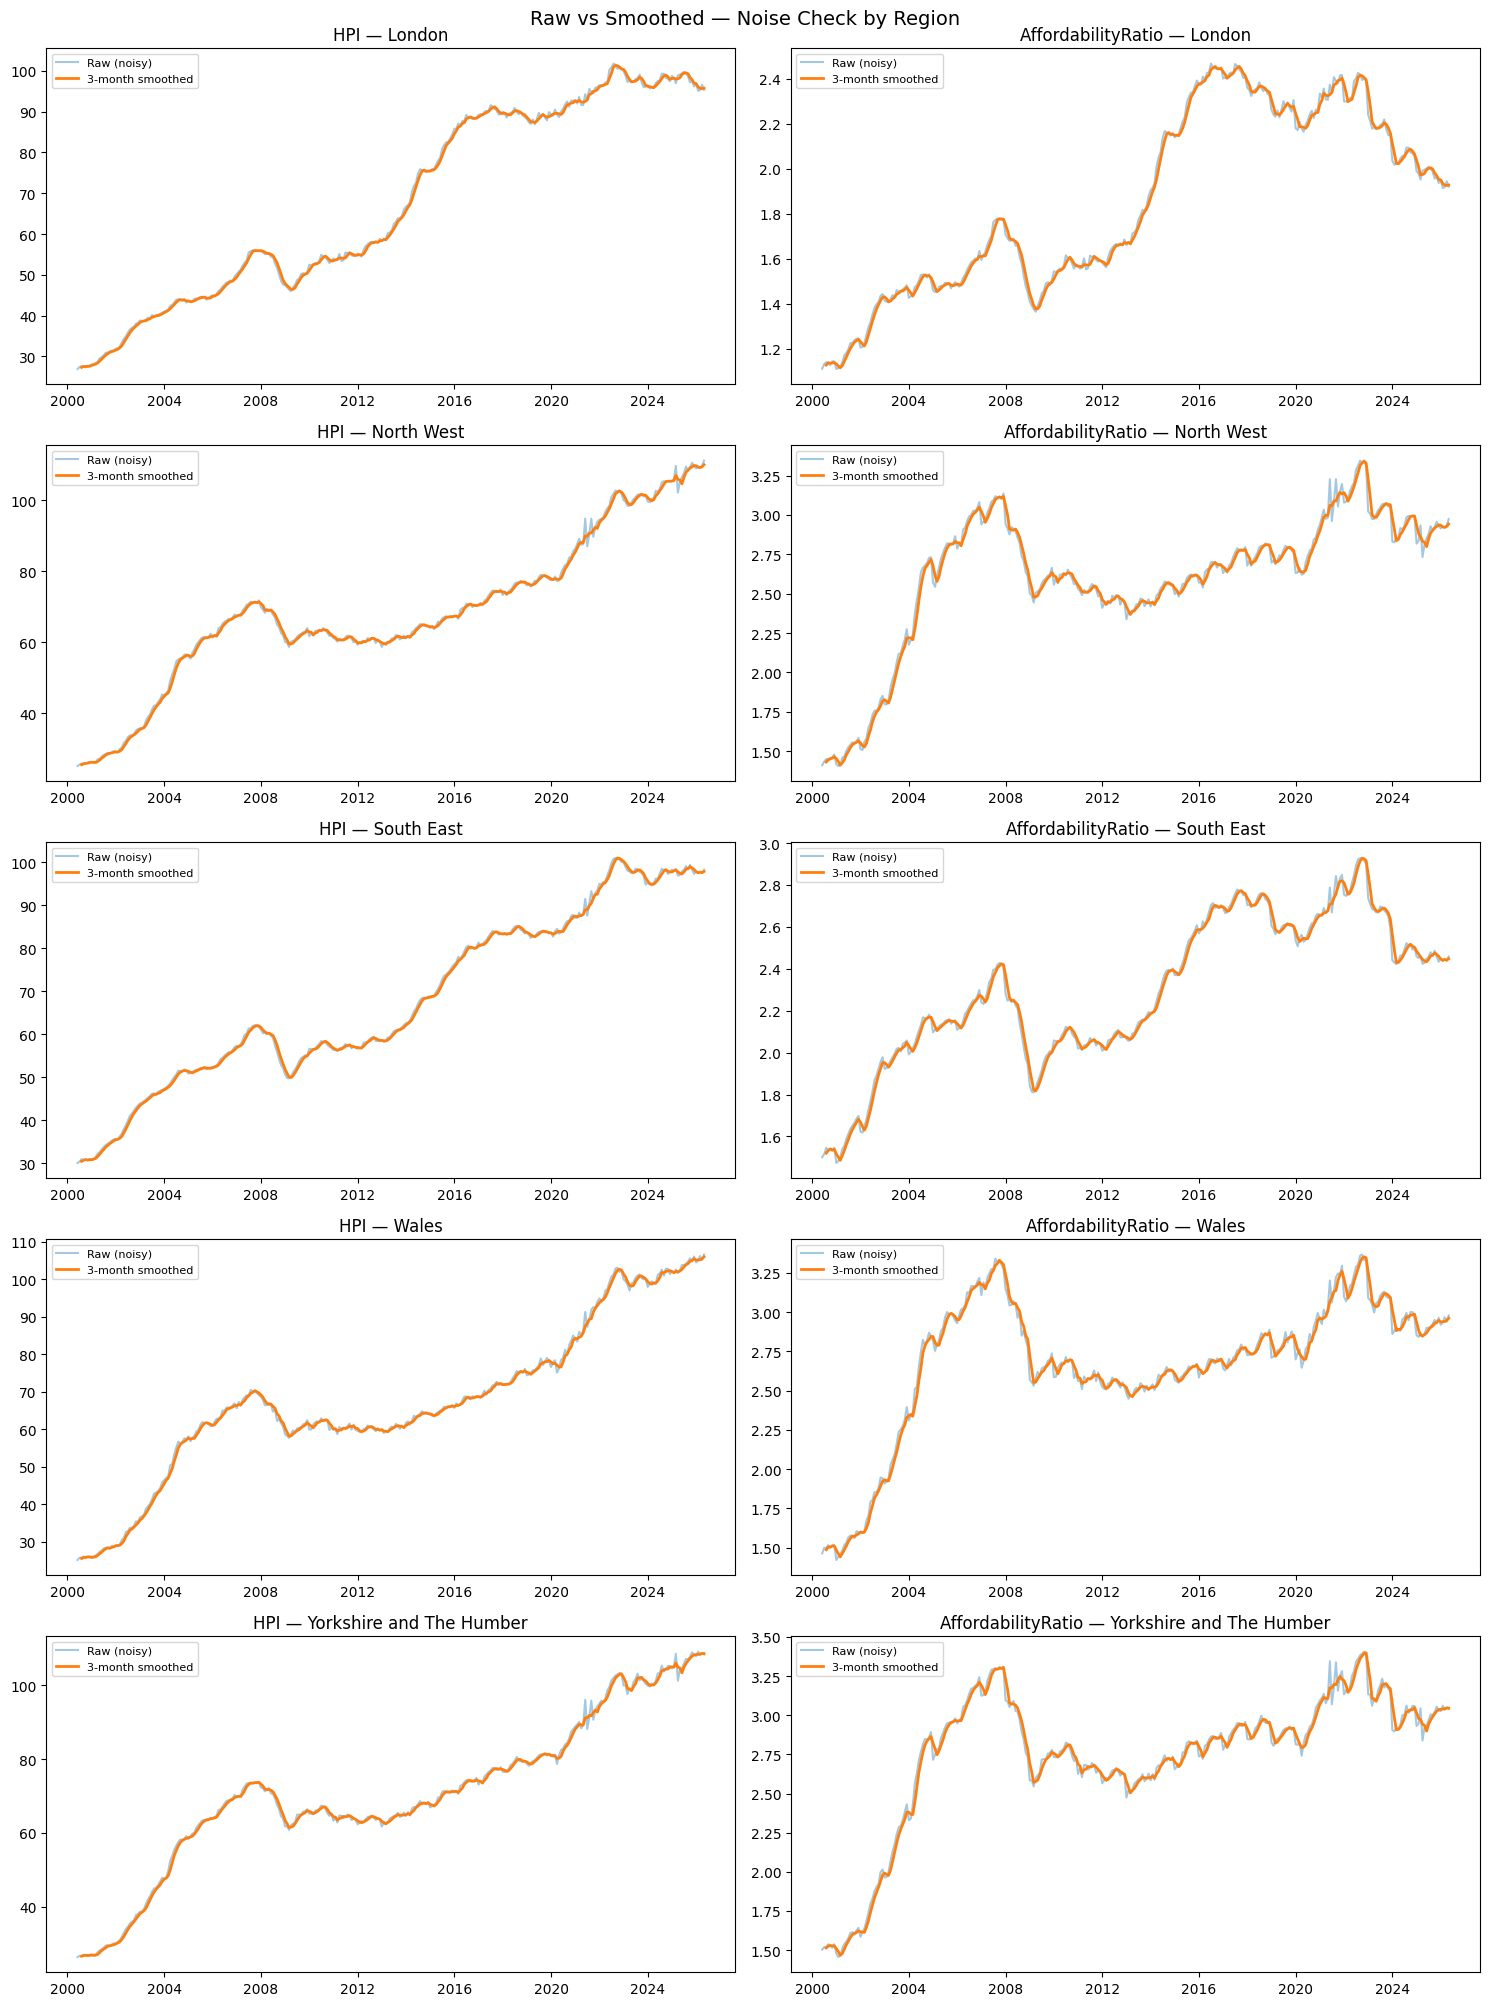

In [20]:
# Noise check across ALL regions — raw vs 3-month smoothed
regions = df['Region'].unique()

fig, axes = plt.subplots(len(regions), 2, figsize=(15, 4 * len(regions)))

for r, region in enumerate(regions):
    sub = df[df['Region'] == region].sort_values('Date')
    for i, target in enumerate(['HPI', 'AffordabilityRatio']):
        ax = axes[r, i]
        ax.plot(sub['Date'], sub[target], alpha=0.4, label='Raw (noisy)')
        ax.plot(sub['Date'], sub[target].rolling(3).mean(), linewidth=2, label='3-month smoothed')
        ax.set_title(f"{target} — {region}")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle("Raw vs Smoothed — Noise Check by Region", y=1.001, fontsize=14)
plt.show()

In [21]:
print("Shape:", df.shape)
print("Missing:", df.isnull().sum().sum())
print("Has lag columns already?", any('lag' in c for c in df.columns))

Shape: (1560, 9)
Missing: 10
Has lag columns already? False


In [22]:
base_cols = ['HPI', 'AffordabilityRatio', 'CPI', 'BaseRate', 'MedianAnnualPay']
print(df[base_cols].isnull().sum())

HPI                   0
AffordabilityRatio    0
CPI                   0
BaseRate              0
MedianAnnualPay       0
dtype: int64


## 2. Stationarity Tests + Feature Engineering
Concept what is stationarity? A series is stationary if its statistical behaviour (mean, variance) stays roughly constant over time. Classical models like ARIMA assume this. House prices trend strongly upward, so they are not stationary we test for it and, if needed, difference the series (model month-to-month changes instead of levels).

Two complementary tests:

ADF — null hypothesis = non-stationary. Low p-value (<0.05) → stationary.
KPSS — null hypothesis = stationary. High p-value (≥0.05) → stationary.
Using both cross-checks the conclusion.

Concept — feature engineering with lags and rolling stats. Time-series models learn from the recent past. We create:

Lag features (value 1, 3, 6, 12 months ago) — give the model memory.
Rolling mean / std (3- and 12-month windows) — capture local trend and volatility.
Crucially, these are built per region so one region's history never leaks into another's.

In [23]:
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

regions = df['Region'].unique()

def adf_test(series):
    result = adfuller(series.dropna(), autolag='AIC')
    return {'ADF_stat': result[0], 'ADF_pvalue': result[1], 'ADF_stationary': result[1] < 0.05}

def kpss_test(series):
    result = kpss(series.dropna(), regression='c', nlags='auto')
    return {'KPSS_stat': result[0], 'KPSS_pvalue': result[1], 'KPSS_stationary': result[1] >= 0.05}

results = []
for region in regions:
    sub = df[df['Region'] == region].sort_values('Date')
    for col in ['HPI', 'AffordabilityRatio']:
        adf_r = adf_test(sub[col])
        kpss_r = kpss_test(sub[col])
        results.append({'Region': region, 'Series': col, **adf_r, **kpss_r})
        diff = sub[col].diff().dropna()
        adf_d = adf_test(diff)
        kpss_d = kpss_test(diff)
        results.append({'Region': region, 'Series': col + ' (1st diff)', **adf_d, **kpss_d})

stationarity_df = pd.DataFrame(results)
print(stationarity_df.to_string(index=False))

df = df.sort_values(['Region', 'Date']).reset_index(drop=True)
for col in ['HPI', 'AffordabilityRatio']:
    for lag in [1, 3, 6, 12]:
        df[f'{col}_lag{lag}'] = df.groupby('Region')[col].shift(lag)
    for window in [3, 12]:
        df[f'{col}_rollmean{window}'] = df.groupby('Region')[col].transform(lambda x: x.shift(1).rolling(window).mean())
        df[f'{col}_rollstd{window}'] = df.groupby('Region')[col].transform(lambda x: x.shift(1).rolling(window).std())

print("\nFeature-engineered shape:", df.shape)
df.to_csv('master_dataset_features.csv', index=False)

                  Region                        Series  ADF_stat  ADF_pvalue  ADF_stationary  KPSS_stat  KPSS_pvalue  KPSS_stationary
                  London                           HPI -1.342597    0.609466           False   2.623953     0.010000            False
                  London                HPI (1st diff) -4.440218    0.000252            True   0.228061     0.100000             True
                  London            AffordabilityRatio -1.811084    0.374973           False   2.136356     0.010000            False
                  London AffordabilityRatio (1st diff) -3.164217    0.022152            True   0.406432     0.074383             True
              North West                           HPI -0.691106    0.849040           False   2.233772     0.010000            False
              North West                HPI (1st diff) -3.141868    0.023606            True   0.221594     0.100000             True
              North West            AffordabilityRatio -3.0097

In [24]:
# Lag + rolling features, built per region (no cross-region leakage)
df = df.sort_values(['Region', 'Date']).reset_index(drop=True)
for col in ['HPI', 'AffordabilityRatio']:
    for lag in [1, 3, 6, 12]:
        df[f'{col}_lag{lag}'] = df.groupby('Region')[col].shift(lag)
    for window in [3, 12]:
        df[f'{col}_rollmean{window}'] = df.groupby('Region')[col].transform(lambda x: x.rolling(window).mean())
        df[f'{col}_rollstd{window}']  = df.groupby('Region')[col].transform(lambda x: x.rolling(window).std())

print("Feature-engineered shape:", df.shape)
df.to_csv('master_dataset_features.csv', index=False)

Feature-engineered shape: (1560, 25)


## 3. Baseline Models — Naive Persistence + ARIMA
Concept — why baselines matter. A fancy model is only impressive if it beats a simple one. Two baselines:

Naive persistence — "tomorrow = today". Forecast the next value as the last observed value. Surprisingly hard to beat for smooth series.
ARIMA — the classic statistical forecaster. It combines: AR (regress on past values), I (differencing for stationarity), and MA (regress on past errors). Orders chosen by the Box-Jenkins approach / auto search.

In [25]:
!pip install pmdarima -q

import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm

TRAIN_END = '2022-12-01'
VAL_END = '2024-06-01'
TEST_START = '2024-07-01'
TARGETS = ['HPI', 'AffordabilityRatio']

def rmse(a, p): return np.sqrt(np.mean((a-p)**2))
def mae(a, p): return np.mean(np.abs(a-p))
def mape(a, p): return np.mean(np.abs((a-p)/a)) * 100

results = []
arima_orders = {}

for region in regions:
    sub = df[df['Region'] == region].set_index('Date')
    for target in TARGETS:
        series = sub[target].dropna()
        trainval = series[series.index <= VAL_END]
        test = series[series.index >= TEST_START]

        naive_pred = np.full(len(test), trainval.iloc[-1])
        results.append({'Region': region, 'Target': target, 'Model': 'Naive',
                         'RMSE': rmse(test.values, naive_pred),
                         'MAE': mae(test.values, naive_pred),
                         'MAPE': mape(test.values, naive_pred)})

        auto_model = pm.auto_arima(trainval, d=1, seasonal=False,
                                     start_p=0, start_q=0, max_p=5, max_q=5,
                                     stepwise=True, suppress_warnings=True, error_action='ignore')
        order = auto_model.order
        arima_orders[f'{region}_{target}'] = order

        arima_model = ARIMA(trainval, order=order).fit()
        arima_fc = arima_model.forecast(steps=len(test))
        results.append({'Region': region, 'Target': target, 'Model': f'ARIMA{order}',
                         'RMSE': rmse(test.values, arima_fc.values),
                         'MAE': mae(test.values, arima_fc.values),
                         'MAPE': mape(test.values, arima_fc.values)})
        print(f"{region} | {target} | ARIMA order={order} done")

results_df = pd.DataFrame(results)
results_df.to_csv('baseline_naive_arima_results.csv', index=False)
print("\n=== RESULTS ===")
print(results_df.to_string(index=False))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 6.4 MB/s eta 0:00:00
London | HPI | ARIMA order=(3, 1, 0) done
London | AffordabilityRatio | ARIMA order=(3, 1, 0) done
North West | HPI | ARIMA order=(2, 1, 5) done
North West | AffordabilityRatio | ARIMA order=(0, 1, 0) done
South East | HPI | ARIMA order=(3, 1, 0) done
South East | AffordabilityRatio | ARIMA order=(4, 1, 1) done
Wales | HPI | ARIMA order=(4, 1, 0) done
Wales | AffordabilityRatio | ARIMA order=(0, 1, 0) done
Yorkshire and The Humber | HPI | ARIMA order=(3, 1, 0) done
Yorkshire and The Humber | AffordabilityRatio | ARIMA order=(0, 1, 0) done

=== RESULTS ===
                  Region             Target          Model     RMSE      MAE     MAPE
                  London                HPI          Naive 1.422490 1.217391 1.244384
                  London                HPI ARIMA(3, 1, 0) 1.837790 1.347465 1.394090
                  London AffordabilityRatio          Naive 0.082946 0.071652 3.651499
              

## 4. SARIMA (Seasonal)

In [26]:
import itertools

seasonal_period = 12  # monthly data, yearly seasonality

sarima_results = []
sarima_orders = {}

for region in regions:
    sub = df[df['Region'] == region].set_index('Date')
    for target in TARGETS:
        series = sub[target].dropna()
        trainval = series[series.index <= VAL_END]
        test = series[series.index >= TEST_START]

        auto_sarima = pm.auto_arima(
            trainval, d=1, seasonal=True, m=seasonal_period,
            start_p=0, start_q=0, max_p=3, max_q=3,
            start_P=0, start_Q=0, max_P=2, max_Q=2, max_D=1,
            stepwise=True, suppress_warnings=True, error_action='ignore'
        )
        order = auto_sarima.order
        seasonal_order = auto_sarima.seasonal_order
        sarima_orders[f'{region}_{target}'] = {'order': order, 'seasonal_order': seasonal_order}

        fc = auto_sarima.predict(n_periods=len(test))
        sarima_results.append({
            'Region': region, 'Target': target,
            'Model': f'SARIMA{order}x{seasonal_order}',
            'RMSE': rmse(test.values, np.array(fc)),
            'MAE': mae(test.values, np.array(fc)),
            'MAPE': mape(test.values, np.array(fc))
        })
        print(f"{region} | {target} | SARIMA order={order} seasonal={seasonal_order} done")

sarima_df = pd.DataFrame(sarima_results)
sarima_df.to_csv('sarima_results.csv', index=False)

# Combine with earlier naive/ARIMA results for one master comparison table
all_results = pd.concat([results_df, sarima_df], ignore_index=True)
all_results.to_csv('all_baseline_results.csv', index=False)

print("\n=== SARIMA RESULTS ===")
print(sarima_df.to_string(index=False))

London | HPI | SARIMA order=(3, 1, 0) seasonal=(1, 0, 1, 12) done
London | AffordabilityRatio | SARIMA order=(3, 1, 0) seasonal=(1, 0, 2, 12) done
North West | HPI | SARIMA order=(1, 1, 0) seasonal=(1, 0, 1, 12) done
North West | AffordabilityRatio | SARIMA order=(3, 1, 0) seasonal=(1, 0, 1, 12) done
South East | HPI | SARIMA order=(3, 1, 0) seasonal=(1, 0, 1, 12) done
South East | AffordabilityRatio | SARIMA order=(3, 1, 0) seasonal=(1, 0, 2, 12) done
Wales | HPI | SARIMA order=(1, 1, 0) seasonal=(2, 0, 2, 12) done
Wales | AffordabilityRatio | SARIMA order=(1, 1, 2) seasonal=(2, 0, 2, 12) done
Yorkshire and The Humber | HPI | SARIMA order=(3, 1, 3) seasonal=(1, 0, 1, 12) done
Yorkshire and The Humber | AffordabilityRatio | SARIMA order=(1, 1, 0) seasonal=(1, 0, 2, 12) done

=== SARIMA RESULTS ===
                  Region             Target                         Model     RMSE      MAE     MAPE
                  London                HPI SARIMA(3, 1, 0)x(1, 0, 1, 12) 2.575073 1.85510

In [27]:
def build_single_task_lstm(lookback, n_features=1):
    model = keras.Sequential([
        keras.layers.LSTM(32, activation='tanh', input_shape=(lookback, n_features)),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Trained models get stored here per region so downstream sections can reuse
# them directly rather than retraining (see Sections 5, 6, 7, 8).
single_task_models = {}
multitask_models = {}

## 5. Single-Task LSTM (HPI only)

In [28]:
LOOKBACK = 12

def make_sequences(series, lookback):
    X, y = [], []
    for i in range(lookback, len(series)):
        X.append(series[i-lookback:i])
        y.append(series[i])
    return np.array(X), np.array(y)

lstm_results = []

for region in regions:
    sub = df[df['Region'] == region].set_index('Date')
    series = sub['HPI'].dropna()

    train = series[series.index <= TRAIN_END]
    val = series[(series.index > TRAIN_END) & (series.index <= VAL_END)]
    test = series[series.index >= TEST_START]

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1,1)).flatten()
    full_series = series.values
    full_scaled = scaler.transform(full_series.reshape(-1,1)).flatten()

    train_end_idx = len(train)
    val_end_idx = len(train) + len(val)

    X_all, y_all = make_sequences(full_scaled, LOOKBACK)
    idx_offset = LOOKBACK

    X_train = X_all[:train_end_idx - idx_offset]
    y_train = y_all[:train_end_idx - idx_offset]
    X_val = X_all[train_end_idx - idx_offset: val_end_idx - idx_offset]
    y_val = y_all[train_end_idx - idx_offset: val_end_idx - idx_offset]
    X_test = X_all[val_end_idx - idx_offset:]
    y_test = y_all[val_end_idx - idx_offset:]

    X_train = X_train.reshape(-1, LOOKBACK, 1)
    X_val = X_val.reshape(-1, LOOKBACK, 1)
    X_test = X_test.reshape(-1, LOOKBACK, 1)

    model = build_single_task_lstm(LOOKBACK, 1)
    early_stop = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=100, batch_size=8, callbacks=[early_stop], verbose=0)

    single_task_models[region] = model  # stored for reuse in Sections 7 & 8

    pred_scaled = model.predict(X_test, verbose=0).flatten()
    pred = scaler.inverse_transform(pred_scaled.reshape(-1,1)).flatten()
    actual = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    lstm_results.append({
        'Region': region, 'Target': 'HPI', 'Model': 'Single-task LSTM',
        'RMSE': rmse(actual, pred), 'MAE': mae(actual, pred), 'MAPE': mape(actual, pred)
    })
    print(f"{region} | Single-task LSTM done")

lstm_df = pd.DataFrame(lstm_results)
lstm_df.to_csv('single_task_lstm_results.csv', index=False)
print("\n=== SINGLE-TASK LSTM RESULTS ===")
print(lstm_df.to_string(index=False))

London | Single-task LSTM done
North West | Single-task LSTM done
South East | Single-task LSTM done
Wales | Single-task LSTM done


Yorkshire and The Humber | Single-task LSTM done

=== SINGLE-TASK LSTM RESULTS ===
                  Region Target            Model     RMSE      MAE     MAPE
                  London    HPI Single-task LSTM 1.938735 1.659803 1.687314
              North West    HPI Single-task LSTM 1.976822 1.640144 1.532668
              South East    HPI Single-task LSTM 2.471902 2.349652 2.394628
                   Wales    HPI Single-task LSTM 2.408270 2.269596 2.183757
Yorkshire and The Humber    HPI Single-task LSTM 2.781835 2.578383 2.419832


## 5b. Single-Task LSTM (Multivariate — HPI + macro features)

In [29]:
FEATURES = ['HPI', 'CPI', 'BaseRate', 'MedianAnnualPay']
LOOKBACK = 12

def make_multivar_sequences(data, lookback, target_idx=0):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, target_idx])
    return np.array(X), np.array(y)

lstm_mv_results = []

for region in regions:
    sub = df[df['Region'] == region].set_index('Date').sort_index()
    data_full = sub[FEATURES].dropna()

    train = data_full[data_full.index <= TRAIN_END]
    val = data_full[(data_full.index > TRAIN_END) & (data_full.index <= VAL_END)]
    test = data_full[data_full.index >= TEST_START]

    scaler = MinMaxScaler()
    scaler.fit(train.values)
    full_scaled = scaler.transform(data_full.values)

    train_end_idx = len(train)
    val_end_idx = len(train) + len(val)

    X_all, y_all = make_multivar_sequences(full_scaled, LOOKBACK, target_idx=0)
    idx_offset = LOOKBACK

    X_train = X_all[:train_end_idx - idx_offset]
    y_train = y_all[:train_end_idx - idx_offset]
    X_val = X_all[train_end_idx - idx_offset: val_end_idx - idx_offset]
    y_val = y_all[train_end_idx - idx_offset: val_end_idx - idx_offset]
    X_test = X_all[val_end_idx - idx_offset:]
    y_test = y_all[val_end_idx - idx_offset:]

    model = build_single_task_lstm(LOOKBACK, len(FEATURES))
    early_stop = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=100, batch_size=8, callbacks=[early_stop], verbose=0)

    pred_scaled = model.predict(X_test, verbose=0).flatten()
    dummy = np.zeros((len(pred_scaled), len(FEATURES)))
    dummy[:, 0] = pred_scaled
    pred = scaler.inverse_transform(dummy)[:, 0]

    dummy_y = np.zeros((len(y_test), len(FEATURES)))
    dummy_y[:, 0] = y_test
    actual = scaler.inverse_transform(dummy_y)[:, 0]

    lstm_mv_results.append({
        'Region': region, 'Target': 'HPI', 'Model': 'Single-task LSTM (multivariate)',
        'RMSE': rmse(actual, pred), 'MAE': mae(actual, pred), 'MAPE': mape(actual, pred)
    })
    print(f"{region} | Multivariate Single-task LSTM done")

lstm_mv_df = pd.DataFrame(lstm_mv_results)
lstm_mv_df.to_csv('single_task_lstm_multivariate_results.csv', index=False)
print("\n=== MULTIVARIATE SINGLE-TASK LSTM RESULTS ===")
print(lstm_mv_df.to_string(index=False))

London | Multivariate Single-task LSTM done
North West | Multivariate Single-task LSTM done
South East | Multivariate Single-task LSTM done
Wales | Multivariate Single-task LSTM done
Yorkshire and The Humber | Multivariate Single-task LSTM done

=== MULTIVARIATE SINGLE-TASK LSTM RESULTS ===
                  Region Target                           Model     RMSE      MAE     MAPE
                  London    HPI Single-task LSTM (multivariate) 6.242869 5.900049 6.059581
              North West    HPI Single-task LSTM (multivariate) 1.816788 1.244992 1.177382
              South East    HPI Single-task LSTM (multivariate) 3.078698 2.531546 2.586166
                   Wales    HPI Single-task LSTM (multivariate) 0.894602 0.719013 0.695824
Yorkshire and The Humber    HPI Single-task LSTM (multivariate) 1.883843 1.330963 1.273048


## 6. Multi-Task LSTM (shared encoder, HPI + Affordability heads)

In [30]:
LOOKBACK = 12
ALPHA_GRID = [0.3, 0.4, 0.5, 0.6, 0.7]

def make_multitask_sequences(hpi, afford, lookback):
    X, y_hpi, y_afford = [], [], []
    for i in range(lookback, len(hpi)):
        X.append(np.column_stack([hpi[i-lookback:i], afford[i-lookback:i]]))
        y_hpi.append(hpi[i])
        y_afford.append(afford[i])
    return np.array(X), np.array(y_hpi), np.array(y_afford)

def build_multitask_model(lookback, alpha):
    inputs = keras.Input(shape=(lookback, 2))
    shared = keras.layers.LSTM(32, activation='tanh')(inputs)
    shared = keras.layers.Dense(16, activation='relu')(shared)

    hpi_head = keras.layers.Dense(8, activation='relu')(shared)
    hpi_out = keras.layers.Dense(1, name='hpi_out')(hpi_head)

    afford_head = keras.layers.Dense(8, activation='relu')(shared)
    afford_out = keras.layers.Dense(1, name='afford_out')(afford_head)

    model = keras.Model(inputs=inputs, outputs=[hpi_out, afford_out])
    model.compile(optimizer='adam',
                  loss={'hpi_out': 'mse', 'afford_out': 'mse'},
                  loss_weights={'hpi_out': alpha, 'afford_out': 1 - alpha})
    return model

multitask_results = []
best_alphas = {}

for region in regions:
    sub = df[df['Region'] == region].set_index('Date').sort_index()
    hpi_series = sub['HPI'].dropna()
    afford_series = sub['AffordabilityRatio'].dropna()

    train_h = hpi_series[hpi_series.index <= TRAIN_END]
    val_h = hpi_series[(hpi_series.index > TRAIN_END) & (hpi_series.index <= VAL_END)]
    test_h = hpi_series[hpi_series.index >= TEST_START]

    scaler_h = MinMaxScaler().fit(train_h.values.reshape(-1,1))
    scaler_a = MinMaxScaler().fit(afford_series[afford_series.index <= TRAIN_END].values.reshape(-1,1))

    hpi_scaled = scaler_h.transform(hpi_series.values.reshape(-1,1)).flatten()
    afford_scaled = scaler_a.transform(afford_series.values.reshape(-1,1)).flatten()

    X_all, y_hpi_all, y_afford_all = make_multitask_sequences(hpi_scaled, afford_scaled, LOOKBACK)

    train_end_idx = len(train_h) - LOOKBACK
    val_end_idx = train_end_idx + len(val_h)

    X_train, y_hpi_train, y_afford_train = X_all[:train_end_idx], y_hpi_all[:train_end_idx], y_afford_all[:train_end_idx]
    X_val, y_hpi_val, y_afford_val = X_all[train_end_idx:val_end_idx], y_hpi_all[train_end_idx:val_end_idx], y_afford_all[train_end_idx:val_end_idx]
    X_test, y_hpi_test, y_afford_test = X_all[val_end_idx:], y_hpi_all[val_end_idx:], y_afford_all[val_end_idx:]

    best_val_loss = np.inf
    best_alpha = None
    best_model = None

    for alpha in ALPHA_GRID:
        model = build_multitask_model(LOOKBACK, alpha)
        early_stop = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
        history = model.fit(X_train, {'hpi_out': y_hpi_train, 'afford_out': y_afford_train},
                             validation_data=(X_val, {'hpi_out': y_hpi_val, 'afford_out': y_afford_val}),
                             epochs=100, batch_size=8, callbacks=[early_stop], verbose=0)
        val_loss = min(history.history['val_loss'])
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_alpha = alpha
            best_model = model

    best_alphas[region] = best_alpha
    multitask_models[region] = best_model  # stored for reuse in Sections 7 & 8b

    pred_hpi_scaled, pred_afford_scaled = best_model.predict(X_test, verbose=0)
    pred_hpi = scaler_h.inverse_transform(pred_hpi_scaled).flatten()
    pred_afford = scaler_a.inverse_transform(pred_afford_scaled).flatten()
    actual_hpi = scaler_h.inverse_transform(y_hpi_test.reshape(-1,1)).flatten()
    actual_afford = scaler_a.inverse_transform(y_afford_test.reshape(-1,1)).flatten()

    multitask_results.append({'Region': region, 'Target': 'HPI', 'Model': f'Multi-task LSTM (α={best_alpha})',
                               'RMSE': rmse(actual_hpi, pred_hpi), 'MAE': mae(actual_hpi, pred_hpi), 'MAPE': mape(actual_hpi, pred_hpi)})
    multitask_results.append({'Region': region, 'Target': 'AffordabilityRatio', 'Model': f'Multi-task LSTM (α={best_alpha})',
                               'RMSE': rmse(actual_afford, pred_afford), 'MAE': mae(actual_afford, pred_afford), 'MAPE': mape(actual_afford, pred_afford)})

    print(f"{region} | best alpha={best_alpha} | done")

multitask_df = pd.DataFrame(multitask_results)
multitask_df.to_csv('multitask_lstm_results.csv', index=False)
print("\n=== MULTI-TASK LSTM RESULTS ===")
print(multitask_df.to_string(index=False))
print("\nBest alphas per region:", best_alphas)

London | best alpha=0.6 | done
North West | best alpha=0.7 | done
South East | best alpha=0.7 | done
Wales | best alpha=0.7 | done
Yorkshire and The Humber | best alpha=0.6 | done

=== MULTI-TASK LSTM RESULTS ===
                  Region             Target                   Model     RMSE      MAE     MAPE
                  London                HPI Multi-task LSTM (α=0.6) 4.341970 4.226214 4.308997
                  London AffordabilityRatio Multi-task LSTM (α=0.6) 0.071571 0.062555 3.185084
              North West                HPI Multi-task LSTM (α=0.7) 6.355067 6.080626 5.635594
              North West AffordabilityRatio Multi-task LSTM (α=0.7) 0.163387 0.149114 5.170235
              South East                HPI Multi-task LSTM (α=0.7) 2.418664 2.224942 2.267878
              South East AffordabilityRatio Multi-task LSTM (α=0.7) 0.070488 0.065257 2.650414
                   Wales                HPI Multi-task LSTM (α=0.7) 4.607802 4.386160 4.213818
                   Wales Af

## 7. Diebold-Mariano Test — Multi-task vs Single-task LSTM

In [31]:
from scipy.stats import t as t_dist

def diebold_mariano(errors1, errors2, h=1):
    """Diebold-Mariano test. errors1, errors2: forecast errors (actual - predicted) from two models.
    Tests H0: both models have equal predictive accuracy."""
    d = errors1**2 - errors2**2
    n = len(d)
    d_mean = np.mean(d)
    d_var = np.var(d, ddof=1)
    dm_stat = d_mean / np.sqrt(d_var / n)
    p_value = 2 * (1 - t_dist.cdf(np.abs(dm_stat), df=n-1))
    return dm_stat, p_value

dm_results = []

for region in regions:
    sub = df[df['Region'] == region].set_index('Date').sort_index()
    hpi_series = sub['HPI'].dropna()
    afford_series = sub['AffordabilityRatio'].dropna()

    train_h = hpi_series[hpi_series.index <= TRAIN_END]
    val_h = hpi_series[(hpi_series.index > TRAIN_END) & (hpi_series.index <= VAL_END)]
    test_h = hpi_series[hpi_series.index >= TEST_START]

    scaler_h = MinMaxScaler().fit(train_h.values.reshape(-1,1))
    scaler_a = MinMaxScaler().fit(afford_series[afford_series.index <= TRAIN_END].values.reshape(-1,1))
    hpi_scaled = scaler_h.transform(hpi_series.values.reshape(-1,1)).flatten()
    afford_scaled = scaler_a.transform(afford_series.values.reshape(-1,1)).flatten()

    # ---- Single-task (HPI only) ----
    X_all_s, y_all_s = make_sequences(hpi_scaled, LOOKBACK)
    train_end_idx = len(train_h) - LOOKBACK
    val_end_idx = train_end_idx + len(val_h)
    X_train_s, y_train_s = X_all_s[:train_end_idx], y_all_s[:train_end_idx]
    X_val_s, y_val_s = X_all_s[train_end_idx:val_end_idx], y_all_s[train_end_idx:val_end_idx]
    X_test_s, y_test_s = X_all_s[val_end_idx:], y_all_s[val_end_idx:]
    X_train_s, X_val_s, X_test_s = [x.reshape(-1, LOOKBACK, 1) for x in [X_train_s, X_val_s, X_test_s]]

    # Reuse the exact trained model from Section 5 instead of retraining a fresh
    # copy — keeps this significance test consistent with the RMSE already
    # reported there, rather than testing a different set of random weights.
    single_model = single_task_models[region]
    pred_s_scaled = single_model.predict(X_test_s, verbose=0).flatten()
    pred_single = scaler_h.inverse_transform(pred_s_scaled.reshape(-1,1)).flatten()
    actual_single = scaler_h.inverse_transform(y_test_s.reshape(-1,1)).flatten()
    errors_single = actual_single - pred_single

    # ---- Multi-task, using best alpha already found ----
    alpha = best_alphas[region]
    X_all_m, y_hpi_all, y_afford_all = make_multitask_sequences(hpi_scaled, afford_scaled, LOOKBACK)
    X_train_m, y_hpi_train, y_afford_train = X_all_m[:train_end_idx], y_hpi_all[:train_end_idx], y_afford_all[:train_end_idx]
    X_val_m, y_hpi_val, y_afford_val = X_all_m[train_end_idx:val_end_idx], y_hpi_all[train_end_idx:val_end_idx], y_afford_all[train_end_idx:val_end_idx]
    X_test_m, y_hpi_test, y_afford_test = X_all_m[val_end_idx:], y_hpi_all[val_end_idx:], y_afford_all[val_end_idx:]

    # Same principle: reuse the trained multi-task model from Section 6.
    mt_model = multitask_models[region]
    pred_hpi_scaled, _ = mt_model.predict(X_test_m, verbose=0)
    pred_multi = scaler_h.inverse_transform(pred_hpi_scaled).flatten()
    actual_multi = scaler_h.inverse_transform(y_hpi_test.reshape(-1,1)).flatten()
    errors_multi = actual_multi - pred_multi

    dm_stat, p_val = diebold_mariano(errors_single, errors_multi)
    dm_results.append({
        'Region': region,
        'DM_statistic': dm_stat,
        'p_value': p_val,
        'Significant_at_0.05': p_val < 0.05,
        'Better_model': 'Multi-task' if dm_stat > 0 else 'Single-task'
    })
    print(f"{region} | DM stat={dm_stat:.3f} | p={p_val:.4f} | done")

dm_df = pd.DataFrame(dm_results)
dm_df.to_csv('diebold_mariano_results.csv', index=False)
print("\n=== DIEBOLD-MARIANO TEST RESULTS ===")
print(dm_df.to_string(index=False))
print("\nNote: DM_statistic > 0 means single-task LSTM has lower squared error (better);")
print("DM_statistic < 0 means multi-task LSTM has lower squared error (better).")

London | DM stat=-9.704 | p=0.0000 | done
North West | DM stat=-8.473 | p=0.0000 | done
South East | DM stat=0.319 | p=0.7525 | done
Wales | DM stat=-7.123 | p=0.0000 | done
Yorkshire and The Humber | DM stat=-4.755 | p=0.0001 | done

=== DIEBOLD-MARIANO TEST RESULTS ===
                  Region  DM_statistic      p_value  Significant_at_0.05 Better_model
                  London     -9.703995 2.079538e-09                 True  Single-task
              North West     -8.472754 2.246480e-08                 True  Single-task
              South East      0.319374 7.524555e-01                False   Multi-task
                   Wales     -7.122934 3.835822e-07                 True  Single-task
Yorkshire and The Humber     -4.755382 9.541983e-05                 True  Single-task

Note: DM_statistic > 0 means single-task LSTM has lower squared error (better);
DM_statistic < 0 means multi-task LSTM has lower squared error (better).


In [32]:
from statsmodels.tsa.arima.model import ARIMA as ARIMA_bt

N_BACKTEST = 24
backtest_results = []

for region in regions:
    sub = df[df['Region'] == region].set_index('Date').sort_index()

    for target in TARGETS:
        series = sub[target].dropna()
        if len(series) <= N_BACKTEST + 12:
            continue
        backtest_dates = series.index[-N_BACKTEST:]

        naive_preds, naive_actuals = [], []
        for d in backtest_dates:
            history = series[series.index < d]
            naive_preds.append(history.iloc[-1])
            naive_actuals.append(series[d])
        naive_preds, naive_actuals = np.array(naive_preds), np.array(naive_actuals)
        backtest_results.append({'Region': region, 'Target': target, 'Model': 'Naive',
                                  'RMSE': rmse(naive_actuals, naive_preds),
                                  'MAE': mae(naive_actuals, naive_preds),
                                  'MAPE': mape(naive_actuals, naive_preds)})

        order = arima_orders.get(f'{region}_{target}')
        if order is not None:
            arima_preds, arima_actuals = [], []
            for d in backtest_dates:
                history = series[series.index < d]
                try:
                    fitted = ARIMA_bt(history, order=order).fit()
                    arima_preds.append(fitted.forecast(steps=1).values[0])
                    arima_actuals.append(series[d])
                except Exception:
                    continue
            if arima_preds:
                arima_preds, arima_actuals = np.array(arima_preds), np.array(arima_actuals)
                backtest_results.append({'Region': region, 'Target': target, 'Model': f'ARIMA{order} (rolling refit)',
                                          'RMSE': rmse(arima_actuals, arima_preds),
                                          'MAE': mae(arima_actuals, arima_preds),
                                          'MAPE': mape(arima_actuals, arima_preds)})

        sar = sarima_orders.get(f'{region}_{target}')
        if sar is not None:
            sarima_preds, sarima_actuals = [], []
            for d in backtest_dates:
                history = series[series.index < d]
                try:
                    fitted = ARIMA_bt(history, order=sar['order'], seasonal_order=sar['seasonal_order']).fit()
                    sarima_preds.append(fitted.forecast(steps=1).values[0])
                    sarima_actuals.append(series[d])
                except Exception:
                    continue
            if sarima_preds:
                sarima_preds, sarima_actuals = np.array(sarima_preds), np.array(sarima_actuals)
                backtest_results.append({'Region': region, 'Target': target, 'Model': f'SARIMA{sar["order"]}x{sar["seasonal_order"]} (rolling refit)',
                                          'RMSE': rmse(sarima_actuals, sarima_preds),
                                          'MAE': mae(sarima_actuals, sarima_preds),
                                          'MAPE': mape(sarima_actuals, sarima_preds)})

        if target == 'HPI' and region in single_task_models:
            train_h = series[series.index <= TRAIN_END]
            scaler = MinMaxScaler().fit(train_h.values.reshape(-1, 1))
            full_scaled = scaler.transform(series.values.reshape(-1, 1)).flatten()
            model = single_task_models[region]
            lstm_preds, lstm_actuals = [], []
            for d in backtest_dates:
                pos = series.index.get_loc(d)
                if pos < LOOKBACK:
                    continue
                X = full_scaled[pos-LOOKBACK:pos].reshape(1, LOOKBACK, 1)
                pred_scaled = model.predict(X, verbose=0).flatten()[0]
                pred = scaler.inverse_transform([[pred_scaled]])[0, 0]
                lstm_preds.append(pred)
                lstm_actuals.append(series[d])
            if lstm_preds:
                lstm_preds, lstm_actuals = np.array(lstm_preds), np.array(lstm_actuals)
                backtest_results.append({'Region': region, 'Target': target, 'Model': 'Single-task LSTM (rolling, no retrain)',
                                          'RMSE': rmse(lstm_actuals, lstm_preds),
                                          'MAE': mae(lstm_actuals, lstm_preds),
                                          'MAPE': mape(lstm_actuals, lstm_preds)})

        if region in multitask_models:
            hpi_series = sub['HPI'].dropna()
            afford_series = sub['AffordabilityRatio'].dropna()
            train_h = hpi_series[hpi_series.index <= TRAIN_END]
            scaler_h = MinMaxScaler().fit(train_h.values.reshape(-1, 1))
            scaler_a = MinMaxScaler().fit(afford_series[afford_series.index <= TRAIN_END].values.reshape(-1, 1))
            hpi_scaled = scaler_h.transform(hpi_series.values.reshape(-1, 1)).flatten()
            afford_scaled = scaler_a.transform(afford_series.values.reshape(-1, 1)).flatten()
            mt_model = multitask_models[region]
            mt_preds, mt_actuals = [], []
            for d in backtest_dates:
                if d not in hpi_series.index:
                    continue
                pos = hpi_series.index.get_loc(d)
                if pos < LOOKBACK:
                    continue
                X = np.column_stack([hpi_scaled[pos-LOOKBACK:pos], afford_scaled[pos-LOOKBACK:pos]]).reshape(1, LOOKBACK, 2)
                pred_hpi_scaled, pred_afford_scaled = mt_model.predict(X, verbose=0)
                if target == 'HPI':
                    pred = scaler_h.inverse_transform(pred_hpi_scaled)[0, 0]
                else:
                    pred = scaler_a.inverse_transform(pred_afford_scaled)[0, 0]
                mt_preds.append(pred)
                mt_actuals.append(series[d])
            if mt_preds:
                mt_preds, mt_actuals = np.array(mt_preds), np.array(mt_actuals)
                backtest_results.append({'Region': region, 'Target': target, 'Model': 'Multi-task LSTM (rolling, no retrain)',
                                          'RMSE': rmse(mt_actuals, mt_preds),
                                          'MAE': mae(mt_actuals, mt_preds),
                                          'MAPE': mape(mt_actuals, mt_preds)})

        print(f"{region} | {target} | rolling backtest done")

backtest_df = pd.DataFrame(backtest_results)
backtest_df.to_csv('rolling_backtest_results.csv', index=False)
print("\n=== ROLLING 24-MONTH BACKTEST RESULTS ===")
print(backtest_df.to_string(index=False))

London | HPI | rolling backtest done
London | AffordabilityRatio | rolling backtest done
North West | HPI | rolling backtest done
North West | AffordabilityRatio | rolling backtest done
South East | HPI | rolling backtest done
South East | AffordabilityRatio | rolling backtest done
Wales | HPI | rolling backtest done
Wales | AffordabilityRatio | rolling backtest done
Yorkshire and The Humber | HPI | rolling backtest done
Yorkshire and The Humber | AffordabilityRatio | rolling backtest done

=== ROLLING 24-MONTH BACKTEST RESULTS ===
                  Region             Target                                         Model     RMSE      MAE     MAPE
                  London                HPI                                         Naive 0.993730 0.816667 0.837674
                  London                HPI                ARIMA(3, 1, 0) (rolling refit) 0.992688 0.852169 0.873240
                  London                HPI SARIMA(3, 1, 0)x(1, 0, 1, 12) (rolling refit) 0.825205 0.771092 0.7

In [33]:
N_BOOTSTRAP = 1000
bootstrap_results = []

for region in regions:
    if region not in multitask_models:
        continue
    sub = df[df['Region'] == region].set_index('Date').sort_index()
    hpi_series = sub['HPI'].dropna()
    afford_series = sub['AffordabilityRatio'].dropna()

    train_h = hpi_series[hpi_series.index <= TRAIN_END]
    val_h = hpi_series[(hpi_series.index > TRAIN_END) & (hpi_series.index <= VAL_END)]
    scaler_h = MinMaxScaler().fit(train_h.values.reshape(-1, 1))
    scaler_a = MinMaxScaler().fit(afford_series[afford_series.index <= TRAIN_END].values.reshape(-1, 1))
    hpi_scaled = scaler_h.transform(hpi_series.values.reshape(-1, 1)).flatten()
    afford_scaled = scaler_a.transform(afford_series.values.reshape(-1, 1)).flatten()

    X_all, y_hpi_all, y_afford_all = make_multitask_sequences(hpi_scaled, afford_scaled, LOOKBACK)
    train_end_idx = len(train_h) - LOOKBACK
    val_end_idx = train_end_idx + len(val_h)
    X_test = X_all[val_end_idx:]
    y_afford_test = y_afford_all[val_end_idx:]

    mt_model = multitask_models[region]
    _, pred_afford_scaled = mt_model.predict(X_test, verbose=0)
    pred_afford = scaler_a.inverse_transform(pred_afford_scaled).flatten()
    actual_afford = scaler_a.inverse_transform(y_afford_test.reshape(-1, 1)).flatten()
    residuals = actual_afford - pred_afford

    boot_lowers, boot_uppers = [], []
    rng = np.random.default_rng(SEED)
    for i in range(len(pred_afford)):
        boot_samples = pred_afford[i] + rng.choice(residuals, size=N_BOOTSTRAP, replace=True)
        boot_lowers.append(np.percentile(boot_samples, 5))
        boot_uppers.append(np.percentile(boot_samples, 95))

    mean_width = np.mean(np.array(boot_uppers) - np.array(boot_lowers))
    coverage = np.mean((actual_afford >= boot_lowers) & (actual_afford <= boot_uppers))

    bootstrap_results.append({
        'Region': region, 'Mean_90pct_CI_width': mean_width,
        'Empirical_coverage': coverage, 'N_test_points': len(pred_afford)
    })
    print(f"{region} | mean 90% CI width={mean_width:.4f} | empirical coverage={coverage:.2%}")

bootstrap_df = pd.DataFrame(bootstrap_results)
bootstrap_df.to_csv('bootstrap_ci_affordability.csv', index=False)
print("\n=== BOOTSTRAP CI SUMMARY — AFFORDABILITY RATIO (Multi-task LSTM) ===")
print(bootstrap_df.to_string(index=False))

London | mean 90% CI width=0.1483 | empirical coverage=91.30%
North West | mean 90% CI width=0.2018 | empirical coverage=95.65%
South East | mean 90% CI width=0.0850 | empirical coverage=95.65%
Wales | mean 90% CI width=0.1533 | empirical coverage=91.30%
Yorkshire and The Humber | mean 90% CI width=0.1533 | empirical coverage=95.65%

=== BOOTSTRAP CI SUMMARY — AFFORDABILITY RATIO (Multi-task LSTM) ===
                  Region  Mean_90pct_CI_width  Empirical_coverage  N_test_points
                  London             0.148315            0.913043             23
              North West             0.201840            0.956522             23
              South East             0.085020            0.956522             23
                   Wales             0.153296            0.913043             23
Yorkshire and The Humber             0.153282            0.956522             23


## 8. SHAP Explainability — Single-Task LSTM

In [34]:
import shap

shap_results = {}

for region in regions:
    sub = df[df['Region'] == region].set_index('Date').sort_index()
    hpi_series = sub['HPI'].dropna()

    train_h = hpi_series[hpi_series.index <= TRAIN_END]
    scaler_h = MinMaxScaler().fit(train_h.values.reshape(-1,1))
    hpi_scaled = scaler_h.transform(hpi_series.values.reshape(-1,1)).flatten()

    X_all, y_all = make_sequences(hpi_scaled, LOOKBACK)
    train_end_idx = len(train_h) - LOOKBACK
    val_end_idx = train_end_idx + len(hpi_series[(hpi_series.index > TRAIN_END) & (hpi_series.index <= VAL_END)])

    X_train = X_all[:train_end_idx].reshape(-1, LOOKBACK, 1)
    X_test = X_all[val_end_idx:].reshape(-1, LOOKBACK, 1)

    # Reuse the trained model from Section 5 instead of retraining a fresh copy,
    # so the SHAP explanation matches the exact model whose RMSE was reported
    # there (rather than a different, freshly-initialized set of weights).
    model = single_task_models[region]

    # Import shap and perform explanation
    background = X_train[np.random.choice(X_train.shape[0], min(100, X_train.shape[0]), replace=False)]

    def predict_function(x):
        return model.predict(x.reshape(-1, LOOKBACK, 1))

    masker = shap.maskers.Independent(data=background.squeeze(axis=-1))
    explainer = shap.Explainer(predict_function, masker=masker)
    shap_values = explainer(X_test[:min(50, len(X_test))].squeeze(axis=-1)).values

    sv = np.array(shap_values).squeeze()
    mean_abs_shap_per_lag = np.abs(sv).mean(axis=0)
    shap_results[region] = mean_abs_shap_per_lag
    print(f"{region} | SHAP done | most important lag (months back): {LOOKBACK - np.argmax(mean_abs_shap_per_lag)}")

shap_df = pd.DataFrame(shap_results, index=[f'{LOOKBACK-i} months ago' for i in range(LOOKBACK)])
shap_df.to_csv('shap_lag_importance.csv')
print("\n=== SHAP: Average |importance| per lag position, per region ===")
print(shap_df.to_string())

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer:   4%|▍         | 1/23 [00:00<?, ?it/s]

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


PermutationExplainer explainer:  13%|█▎        | 3/23 [00:22<01:11,  3.59s/it]

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


...

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


PermutationExplainer explainer: 100%|██████████| 23/23 [02:40<00:00,  7.35s/it]

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


PermutationExplainer explainer: 24it [02:47,  7.62s/it]

Yorkshire and The Humber | SHAP done | most important lag (months back): 3

=== SHAP: Average |importance| per lag position, per region ===
                 London  North West  South East     Wales  Yorkshire and The Humber
12 months ago  0.020653    0.014956    0.017243  0.015086                  0.018310
11 months ago  0.023835    0.018428    0.019761  0.018349                  0.022686
10 months ago  0.027131    0.022329    0.022437  0.021963                  0.027499
9 months ago   0.030337    0.026806    0.025218  0.025920                  0.032364
8 months ago   0.033525    0.031634    0.028261  0.030298                  0.037471
7 months ago   0.036395    0.036980    0.031289  0.035163                  0.042363
6 months ago   0.038782    0.042796    0.034394  0.040072                  0.046890
5 months ago   0.040679    0.048937    0.037259  0.045253                  0.050819
4 months ago   0.041287    0.055444    0.039882  0.050294                  0.053824
3 months ago   0.040

In [35]:
shap_multitask_results = {}

for region in regions:
    sub = df[df['Region'] == region].set_index('Date').sort_index()
    hpi_series = sub['HPI'].dropna()
    afford_series = sub['AffordabilityRatio'].dropna()

    train_h = hpi_series[hpi_series.index <= TRAIN_END]
    scaler_h = MinMaxScaler().fit(train_h.values.reshape(-1, 1))
    scaler_a = MinMaxScaler().fit(afford_series[afford_series.index <= TRAIN_END].values.reshape(-1, 1))
    hpi_scaled = scaler_h.transform(hpi_series.values.reshape(-1, 1)).flatten()
    afford_scaled = scaler_a.transform(afford_series.values.reshape(-1, 1)).flatten()

    X_all, y_hpi_all, y_afford_all = make_multitask_sequences(hpi_scaled, afford_scaled, LOOKBACK)
    val_h = hpi_series[(hpi_series.index > TRAIN_END) & (hpi_series.index <= VAL_END)]
    train_end_idx = len(train_h) - LOOKBACK
    val_end_idx = train_end_idx + len(val_h)
    X_train = X_all[:train_end_idx]
    X_test = X_all[val_end_idx:]

    mt_model = multitask_models[region]

    background = X_train[np.random.choice(X_train.shape[0], min(100, X_train.shape[0]), replace=False)]
    background_flat = background.reshape(background.shape[0], -1)

    def predict_hpi_output(x_flat):
        x_reshaped = x_flat.reshape(-1, LOOKBACK, 2)
        pred_hpi, _ = mt_model.predict(x_reshaped, verbose=0)
        return pred_hpi

    masker = shap.maskers.Independent(data=background_flat)
    explainer = shap.Explainer(predict_hpi_output, masker=masker)

    n_explain = min(50, len(X_test))
    X_test_flat = X_test[:n_explain].reshape(n_explain, -1)
    shap_values = explainer(X_test_flat).values

    sv = np.array(shap_values).squeeze().reshape(-1, LOOKBACK, 2)
    mean_abs_shap_per_lag = np.abs(sv).mean(axis=(0, 2))
    shap_multitask_results[region] = mean_abs_shap_per_lag
    print(f"{region} | Multi-task SHAP done | most important lag (months back): {LOOKBACK - np.argmax(mean_abs_shap_per_lag)}")

shap_multitask_df = pd.DataFrame(shap_multitask_results, index=[f'{LOOKBACK-i} months ago' for i in range(LOOKBACK)])
shap_multitask_df.to_csv('shap_lag_importance_multitask.csv')
print("\n=== SHAP (Multi-task model): Average |importance| per lag position, per region ===")
print(shap_multitask_df.to_string())

PermutationExplainer explainer: 24it [02:21,  6.44s/it]


London | Multi-task SHAP done | most important lag (months back): 1


PermutationExplainer explainer: 24it [02:23,  6.50s/it]


North West | Multi-task SHAP done | most important lag (months back): 1


PermutationExplainer explainer: 24it [02:21,  6.45s/it]


South East | Multi-task SHAP done | most important lag (months back): 1


PermutationExplainer explainer: 24it [02:25,  6.62s/it]


Wales | Multi-task SHAP done | most important lag (months back): 1


PermutationExplainer explainer: 24it [02:26,  6.64s/it]

Yorkshire and The Humber | Multi-task SHAP done | most important lag (months back): 1

=== SHAP (Multi-task model): Average |importance| per lag position, per region ===
                 London  North West  South East     Wales  Yorkshire and The Humber
12 months ago  0.006803    0.008081    0.005503  0.012223                  0.011236
11 months ago  0.007616    0.009937    0.006500  0.013032                  0.012491
10 months ago  0.008484    0.011755    0.007756  0.013840                  0.013939
9 months ago   0.009385    0.013722    0.009424  0.014879                  0.015458
8 months ago   0.010340    0.015614    0.011537  0.015981                  0.016952
7 months ago   0.011306    0.017534    0.014470  0.016983                  0.018487
6 months ago   0.012232    0.019437    0.018074  0.018302                  0.019889
5 months ago   0.013207    0.021208    0.022220  0.019659                  0.020962
4 months ago   0.014026    0.022473    0.026270  0.021312                 

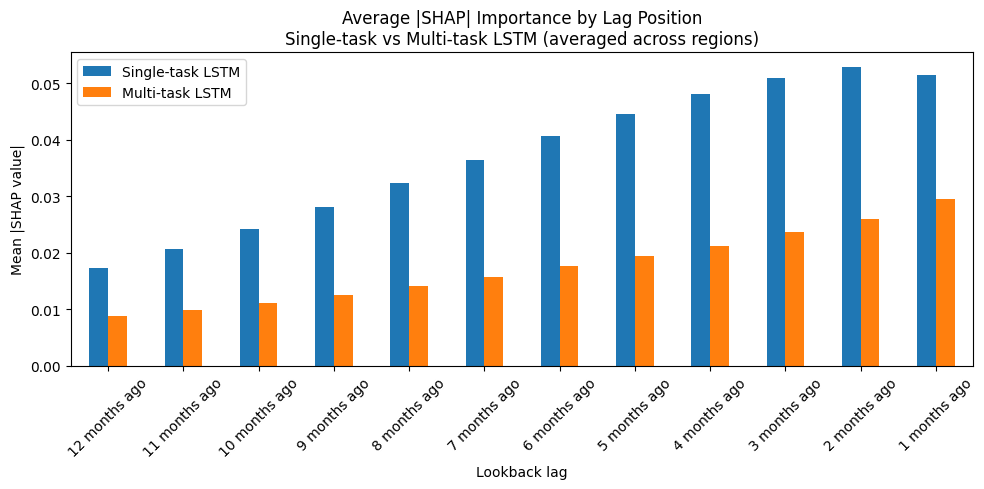

               Single-task LSTM  Multi-task LSTM
12 months ago          0.017250         0.008769
11 months ago          0.020612         0.009915
10 months ago          0.024272         0.011155
9 months ago           0.028129         0.012574
8 months ago           0.032238         0.014085
7 months ago           0.036438         0.015756
6 months ago           0.040587         0.017587
5 months ago           0.044589         0.019451
4 months ago           0.048147         0.021230
3 months ago           0.050945         0.023605
2 months ago           0.052822         0.025930
1 months ago           0.051508         0.029461


In [36]:
import matplotlib.pyplot as plt

shap_single_avg = shap_df.mean(axis=1)
shap_multi_avg = shap_multitask_df.mean(axis=1)

shap_compare = pd.DataFrame({
    'Single-task LSTM': shap_single_avg,
    'Multi-task LSTM': shap_multi_avg
})
shap_compare.to_csv('shap_lag_importance_comparison.csv')

fig, ax = plt.subplots(figsize=(10, 5))
shap_compare.plot(kind='bar', ax=ax)
ax.set_title('Average |SHAP| Importance by Lag Position\nSingle-task vs Multi-task LSTM (averaged across regions)')
ax.set_ylabel('Mean |SHAP value|')
ax.set_xlabel('Lookback lag')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart7_shap_single_vs_multitask.png', dpi=150)
plt.show()
print(shap_compare.to_string())

In [37]:
deep_shap_results = {}
deep_shap_status = {}

for region in regions:
    if region not in single_task_models:
        continue
    model = single_task_models[region]

    sub = df[df['Region'] == region].set_index('Date').sort_index()
    hpi_series = sub['HPI'].dropna()
    train_h = hpi_series[hpi_series.index <= TRAIN_END]
    scaler_h = MinMaxScaler().fit(train_h.values.reshape(-1, 1))
    hpi_scaled = scaler_h.transform(hpi_series.values.reshape(-1, 1)).flatten()

    X_all, y_all = make_sequences(hpi_scaled, LOOKBACK)
    train_end_idx = len(train_h) - LOOKBACK
    X_train = X_all[:train_end_idx].reshape(-1, LOOKBACK, 1)
    X_test = X_all[train_end_idx:].reshape(-1, LOOKBACK, 1)

    try:
        background = X_train[np.random.choice(X_train.shape[0], min(100, X_train.shape[0]), replace=False)]
        explainer = shap.DeepExplainer(model, background)
        shap_values = explainer.shap_values(X_test[:min(50, len(X_test))])
        sv = np.array(shap_values).squeeze()
        deep_shap_results[region] = np.abs(sv).mean(axis=0)
        deep_shap_status[region] = 'success'
        print(f"{region} | DeepExplainer succeeded")
    except Exception as e:
        deep_shap_status[region] = f'failed: {type(e).__name__}: {e}'
        print(f"{region} | DeepExplainer failed ({type(e).__name__}) — falling back to Section 8's Permutation result")

print("\n=== DeepExplainer status per region ===")
for region, status in deep_shap_status.items():
    print(f"{region}: {status}")

if deep_shap_results:
    deep_shap_df = pd.DataFrame(deep_shap_results, index=[f'{LOOKBACK-i} months ago' for i in range(LOOKBACK)])
    deep_shap_df.to_csv('shap_lag_importance_deepexplainer.csv')
    print("\n=== SHAP (DeepExplainer): Average |importance| per lag position ===")
    print(deep_shap_df.to_string())
else:
    print("\nDeepExplainer did not succeed for any region in this environment.")

London | DeepExplainer failed (StagingError) — falling back to Section 8's Permutation result
North West | DeepExplainer failed (StagingError) — falling back to Section 8's Permutation result
South East | DeepExplainer failed (StagingError) — falling back to Section 8's Permutation result
Wales | DeepExplainer failed (StagingError) — falling back to Section 8's Permutation result
Yorkshire and The Humber | DeepExplainer failed (StagingError) — falling back to Section 8's Permutation result

=== DeepExplainer status per region ===
London: failed: StagingError: in user code:

    File "/usr/local/lib/python3.13/dist-packages/shap/explainers/_deep/deep_tf.py", line 265, in grad_graph  *
        x_grad = tape.gradient(out, shap_rAnD)

    LookupError: gradient registry has no entry for: shap_TensorListStack

North West: failed: StagingError: in user code:

    File "/usr/local/lib/python3.13/dist-packages/shap/explainers/_deep/deep_tf.py", line 265, in grad_graph  *
        x_grad = tape.g

## 9. Visualizations — Model Comparison Charts

## 9a. Load All Results

In [38]:
import matplotlib.pyplot as plt

naive_arima = pd.read_csv('baseline_naive_arima_results.csv')
sarima = pd.read_csv('sarima_results.csv')
single_lstm = pd.read_csv('single_task_lstm_results.csv')
multi_lstm = pd.read_csv('multitask_lstm_results.csv')

naive_arima['ModelType'] = naive_arima['Model'].apply(lambda x: 'Naive' if x == 'Naive' else 'ARIMA')
sarima['ModelType'] = 'SARIMA'
single_lstm['ModelType'] = 'Single-task LSTM'
multi_lstm['ModelType'] = 'Multi-task LSTM'

combined = pd.concat([naive_arima, sarima, single_lstm, multi_lstm], ignore_index=True)
print("Combined results loaded:", combined.shape)
print(combined.head())

Combined results loaded: (45, 7)
       Region              Target           Model      RMSE       MAE  \
0      London                 HPI           Naive  1.422490  1.217391   
1      London                 HPI  ARIMA(3, 1, 0)  1.837790  1.347465   
2      London  AffordabilityRatio           Naive  0.082946  0.071652   
3      London  AffordabilityRatio  ARIMA(3, 1, 0)  0.097400  0.083612   
4  North West                 HPI           Naive  5.504978  4.952174   

       MAPE ModelType  
0  1.244384     Naive  
1  1.394090     ARIMA  
2  3.651499     Naive  
3  4.264963     ARIMA  
4  4.569128     Naive  


## 9b. Chart 1 — HPI RMSE Comparison

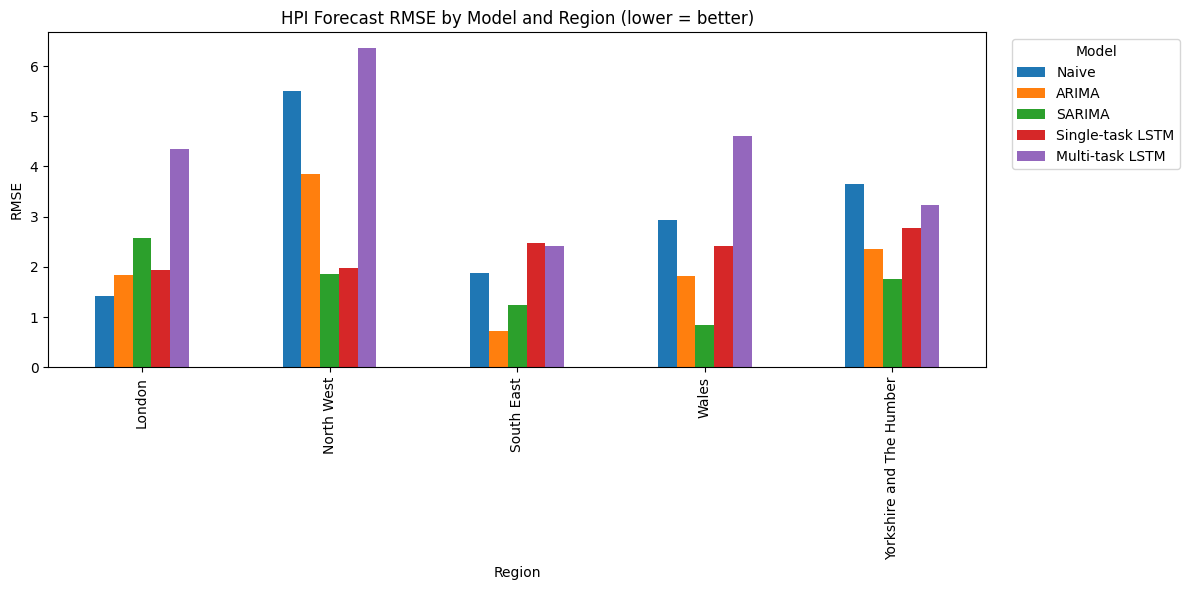

In [39]:
hpi_data = combined[combined['Target'] == 'HPI']
pivot = hpi_data.pivot_table(index='Region', columns='ModelType', values='RMSE', aggfunc='mean')
pivot = pivot[['Naive', 'ARIMA', 'SARIMA', 'Single-task LSTM', 'Multi-task LSTM']]

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax)
ax.set_title('HPI Forecast RMSE by Model and Region (lower = better)')
ax.set_ylabel('RMSE')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart1_hpi_rmse_comparison.png', dpi=150)
plt.show()

## 9c. Chart 2 — Affordability Ratio RMSE Comparison

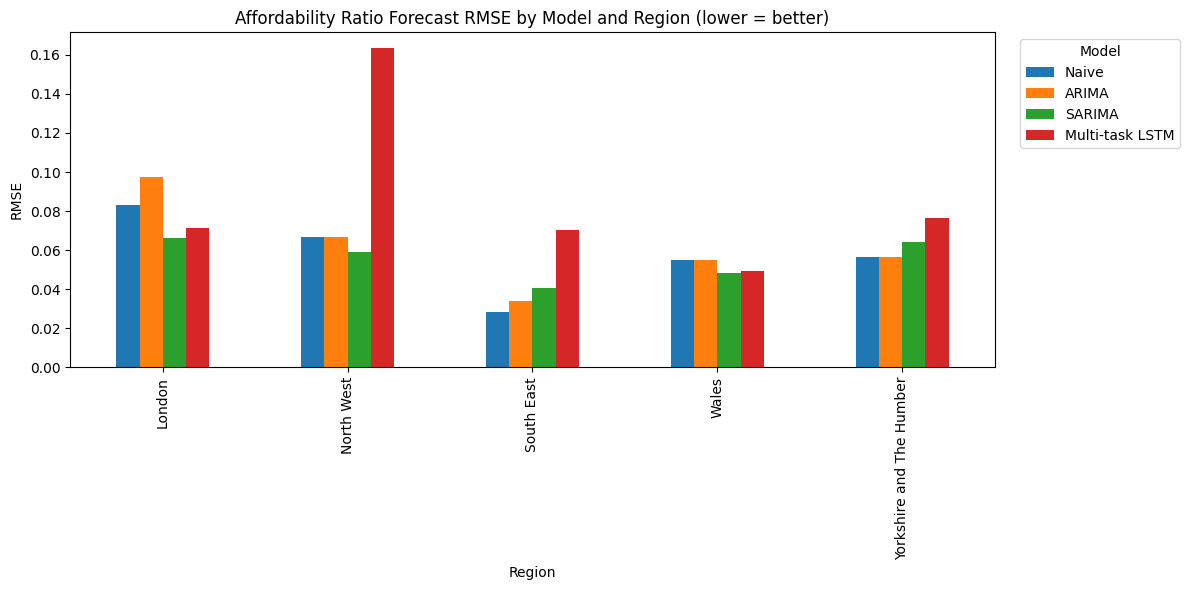

In [40]:
afford_data = combined[combined['Target'] == 'AffordabilityRatio']
pivot2 = afford_data.pivot_table(index='Region', columns='ModelType', values='RMSE', aggfunc='mean')
pivot2 = pivot2[[c for c in ['Naive', 'ARIMA', 'SARIMA', 'Multi-task LSTM'] if c in pivot2.columns]]

fig, ax = plt.subplots(figsize=(12, 6))
pivot2.plot(kind='bar', ax=ax)
ax.set_title('Affordability Ratio Forecast RMSE by Model and Region (lower = better)')
ax.set_ylabel('RMSE')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart2_affordability_rmse_comparison.png', dpi=150)
plt.show()

## 9d. Chart 3 — Diebold-Mariano Test Results

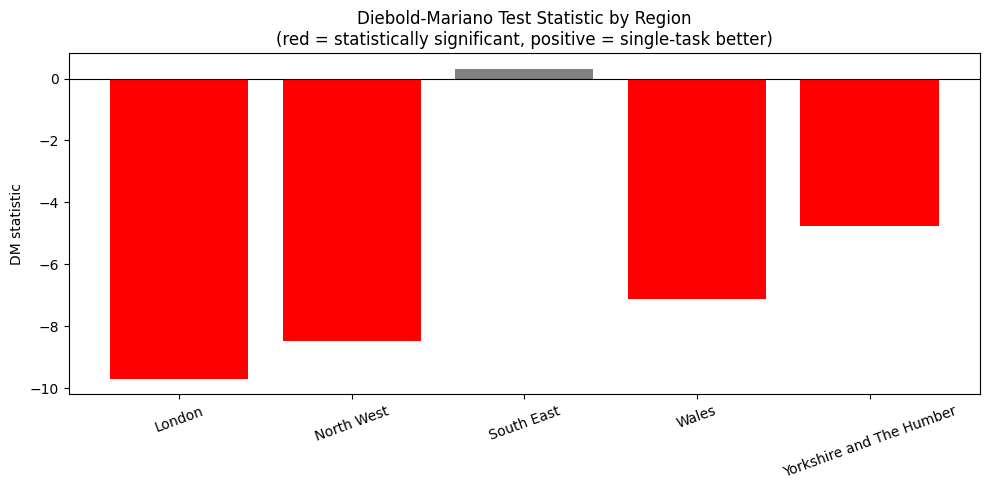

In [41]:
dm = pd.read_csv('diebold_mariano_results.csv')
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['red' if sig else 'grey' for sig in dm['Significant_at_0.05']]
ax.bar(dm['Region'], dm['DM_statistic'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Diebold-Mariano Test Statistic by Region\n(red = statistically significant, positive = single-task better)')
ax.set_ylabel('DM statistic')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('chart3_diebold_mariano.png', dpi=150)
plt.show()

## 9e. Chart 4 — HPI Trends by Region

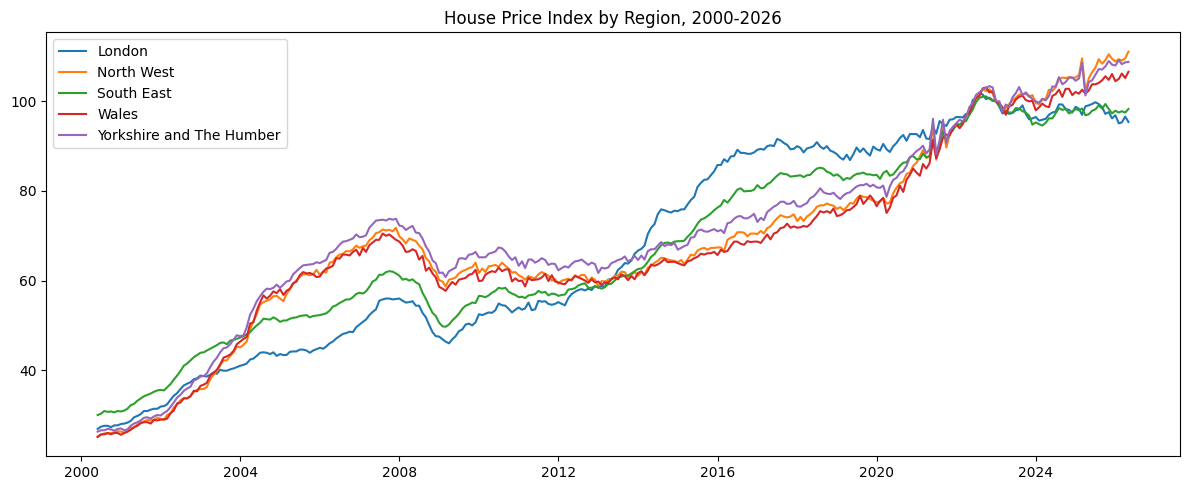

In [42]:
fig, ax = plt.subplots(figsize=(12, 5))
for region in regions:
    sub = df[df['Region'] == region]
    ax.plot(sub['Date'], sub['HPI'], label=region)
ax.set_title('House Price Index by Region, 2000-2026')
ax.legend()
plt.tight_layout()
plt.savefig('chart4_hpi_trends.png', dpi=150)
plt.show()

## 10a. Best Model Per Region

In [43]:
best_per_region = combined.loc[combined.groupby(['Region', 'Target'])['RMSE'].idxmin()]
best_per_region = best_per_region[['Region', 'Target', 'Model', 'RMSE', 'MAE', 'MAPE']].sort_values(['Target', 'Region'])
best_per_region.to_csv('best_model_per_region.csv', index=False)
print(best_per_region.to_string(index=False))

                  Region             Target                         Model     RMSE      MAE     MAPE
                  London AffordabilityRatio SARIMA(3, 1, 0)x(1, 0, 2, 12) 0.066446 0.054554 2.783294
              North West AffordabilityRatio SARIMA(3, 1, 0)x(1, 0, 1, 12) 0.058814 0.049821 1.713998
              South East AffordabilityRatio                         Naive 0.028275 0.023076 0.932249
                   Wales AffordabilityRatio SARIMA(1, 1, 2)x(2, 0, 2, 12) 0.048265 0.039528 1.344786
Yorkshire and The Humber AffordabilityRatio                         Naive 0.056392 0.045678 1.532129
                  London                HPI                         Naive 1.422490 1.217391 1.244384
              North West                HPI SARIMA(1, 1, 0)x(1, 0, 1, 12) 1.866761 1.562959 1.450939
              South East                HPI                ARIMA(3, 1, 0) 0.731596 0.594201 0.606662
                   Wales                HPI SARIMA(1, 1, 0)x(2, 0, 2, 12) 0.836398 0.746503

## 10a-i. Best Model — COVID-19 Period: Original vs Predicted (Train vs Test)

Following supervisor feedback, this section makes the COVID-19 point concrete instead of just
descriptive. For each region's **best-performing model** (from the table above), the original
(actual) series is plotted against that model's predictions, with the plot split into two clearly
marked regions:

- **Training/validation region** (up to Jun 2024) — the model has *seen* this data, including the
  COVID-19 shock (Mar–Dec 2020, shaded). Here the line shown is the model's **in-sample fitted**
  values, i.e. how well it explains data it was trained on.
- **Test region** (Jul–Dec 2024, shaded green) — genuine **out-of-sample forecast**, data the model
  never saw during training. This is the real, honest test of predictive skill.

This directly answers the ToR's claim (§3) that house prices respond to shocks like COVID-19 in
ways a purely linear model may or may not capture — we can now *see* whether the best model tracked
the COVID dip closely (training region) and how it performs once genuinely tested (test region).

In [44]:
# Refit each region's BEST model (per best_per_region table above) to get
# in-sample fitted values (train/val) + out-of-sample forecast (test),
# so we can plot original vs predicted across the whole timeline, including COVID.

import re
from statsmodels.tsa.arima.model import ARIMA as ARIMA_refit
from statsmodels.tsa.statespace.sarimax import SARIMAX

def parse_model_string(model_str):
    if model_str == 'Naive':
        return 'Naive', None, None
    m = re.match(r'SARIMA\((\d+), (\d+), (\d+)\)x\((\d+), (\d+), (\d+), (\d+)\)', model_str)
    if m:
        p, d, q, P, D, Q, s = map(int, m.groups())
        return 'SARIMA', (p, d, q), (P, D, Q, s)
    m = re.match(r'ARIMA\((\d+), (\d+), (\d+)\)', model_str)
    if m:
        p, d, q = map(int, m.groups())
        return 'ARIMA', (p, d, q), None
    return 'Naive', None, None  # LSTM-type winners fall back to Naive-style display

covid_fig_data = {}

for _, row in best_per_region.iterrows():
    region, target, model_str = row['Region'], row['Target'], row['Model']
    sub = df[df['Region'] == region].set_index('Date')
    series = sub[target].dropna()
    trainval = series[series.index <= VAL_END]
    test = series[series.index >= TEST_START]

    kind, order, seasonal_order = parse_model_string(model_str)

    if kind == 'Naive':
        fitted = trainval.shift(1)
        forecast = pd.Series(np.full(len(test), trainval.iloc[-1]), index=test.index)
    elif kind == 'ARIMA':
        fit = ARIMA_refit(trainval, order=order).fit()
        fitted = fit.fittedvalues
        forecast = pd.Series(fit.forecast(steps=len(test)).values, index=test.index)
    else:  # SARIMA
        fit = SARIMAX(trainval, order=order, seasonal_order=seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fitted = fit.fittedvalues
        forecast = pd.Series(fit.forecast(steps=len(test)).values, index=test.index)

    covid_fig_data[(region, target)] = {
        'actual': series, 'fitted': fitted, 'forecast': forecast, 'model': model_str
    }
    print(f"{region} | {target} | best={model_str} | refit for plotting done")

print("\nRefit complete for", len(covid_fig_data), "region/target combinations")

London | AffordabilityRatio | best=SARIMA(3, 1, 0)x(1, 0, 2, 12) | refit for plotting done
North West | AffordabilityRatio | best=SARIMA(3, 1, 0)x(1, 0, 1, 12) | refit for plotting done
South East | AffordabilityRatio | best=Naive | refit for plotting done
Wales | AffordabilityRatio | best=SARIMA(1, 1, 2)x(2, 0, 2, 12) | refit for plotting done
Yorkshire and The Humber | AffordabilityRatio | best=Naive | refit for plotting done
London | HPI | best=Naive | refit for plotting done
North West | HPI | best=SARIMA(1, 1, 0)x(1, 0, 1, 12) | refit for plotting done
South East | HPI | best=ARIMA(3, 1, 0) | refit for plotting done
Wales | HPI | best=SARIMA(1, 1, 0)x(2, 0, 2, 12) | refit for plotting done
Yorkshire and The Humber | HPI | best=SARIMA(3, 1, 3)x(1, 0, 1, 12) | refit for plotting done

Refit complete for 10 region/target combinations


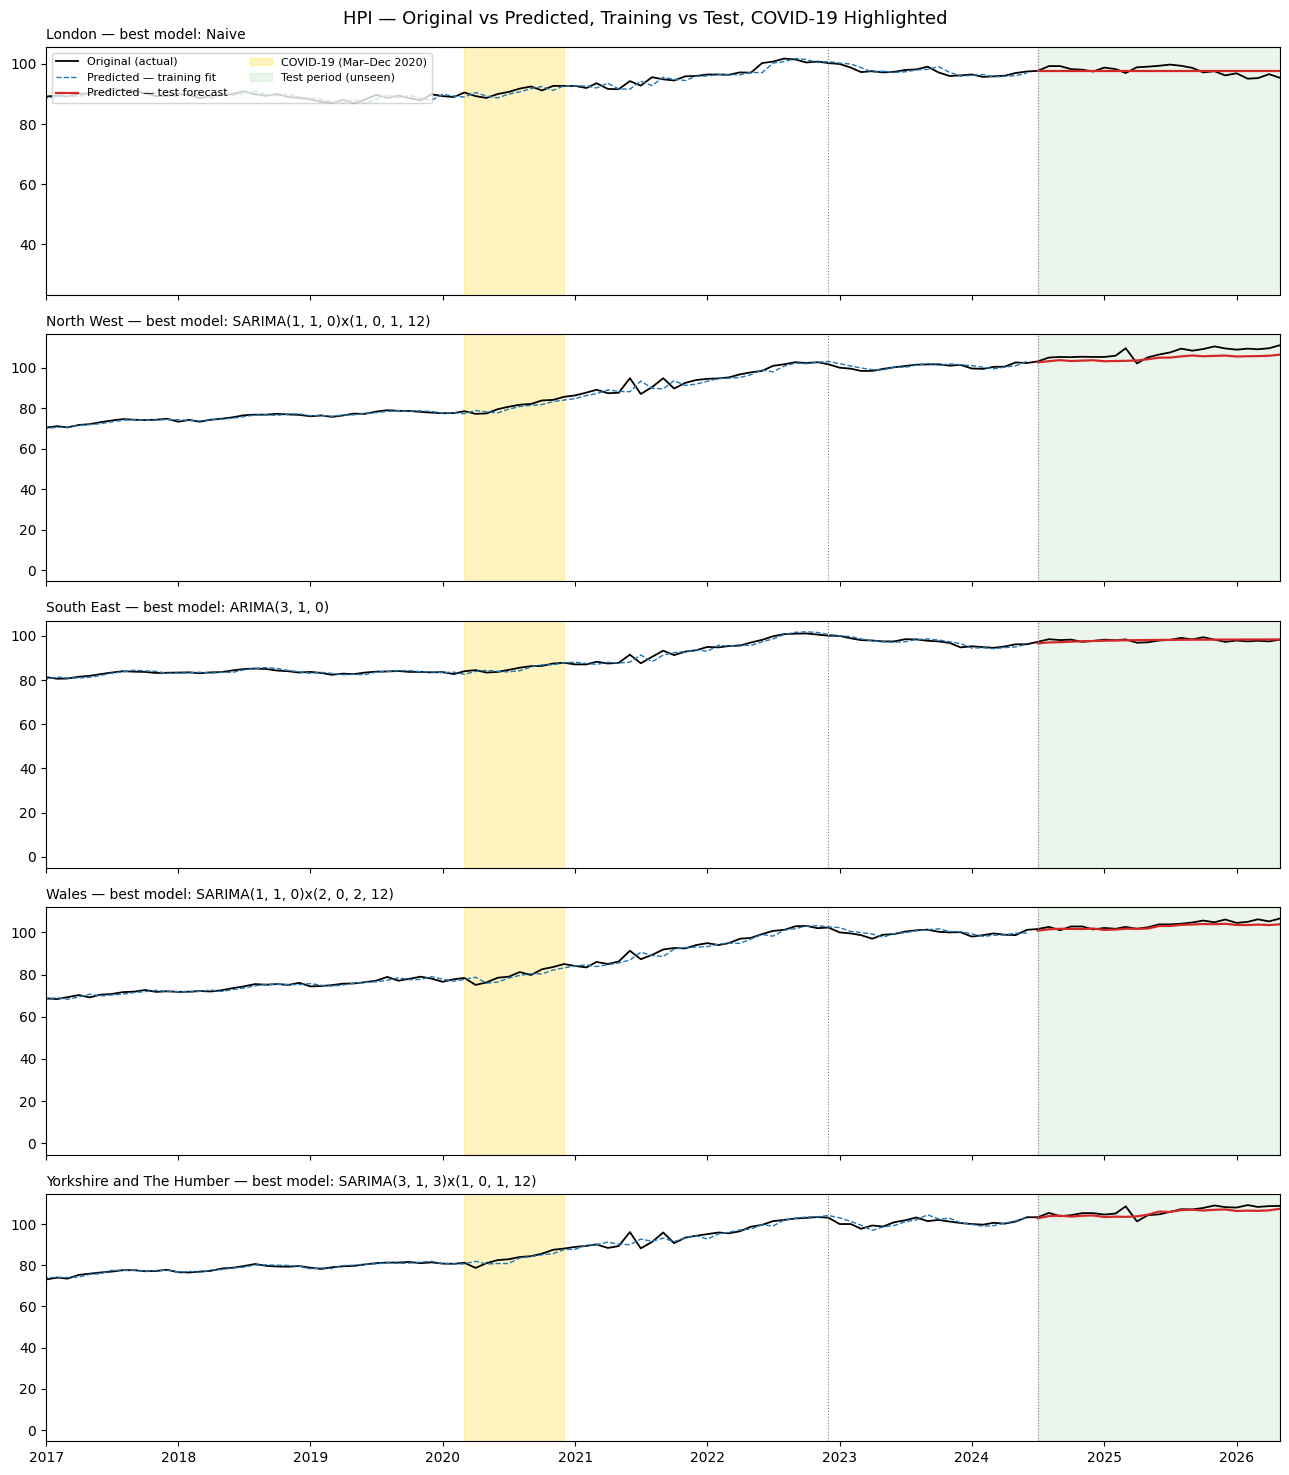

In [45]:
# Plot: Original vs Predicted, Train vs Test, COVID window highlighted — HPI target

fig, axes = plt.subplots(len(regions), 1, figsize=(13, 3 * len(regions)), sharex=True)

covid_start, covid_end = pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-01')
train_end_ts, test_start_ts = pd.Timestamp(TRAIN_END), pd.Timestamp(TEST_START)

for ax, region in zip(axes, regions):
    d = covid_fig_data[(region, 'HPI')]
    ax.plot(d['actual'].index, d['actual'].values, color='black', lw=1.3, label='Original (actual)')
    ax.plot(d['fitted'].index, d['fitted'].values, color='tab:blue', lw=1, ls='--', label='Predicted — training fit')
    ax.plot(d['forecast'].index, d['forecast'].values, color='tab:red', lw=1.6, label='Predicted — test forecast')

    ax.axvspan(covid_start, covid_end, color='gold', alpha=0.25, label='COVID-19 (Mar–Dec 2020)')
    ax.axvspan(test_start_ts, d['actual'].index.max(), color='green', alpha=0.08, label='Test period (unseen)')
    ax.axvline(train_end_ts, color='grey', lw=0.8, ls=':')
    ax.axvline(test_start_ts, color='grey', lw=0.8, ls=':')

    ax.set_title(f"{region} — best model: {d['model']}", fontsize=10, loc='left')
    ax.set_xlim(pd.Timestamp('2017-01-01'), d['actual'].index.max())

axes[0].legend(loc='upper left', fontsize=8, ncol=2)
fig.suptitle('HPI — Original vs Predicted, Training vs Test, COVID-19 Highlighted', fontsize=13)
plt.tight_layout()
plt.savefig('chart_covid_hpi_original_vs_predicted.png', dpi=150)
plt.show()

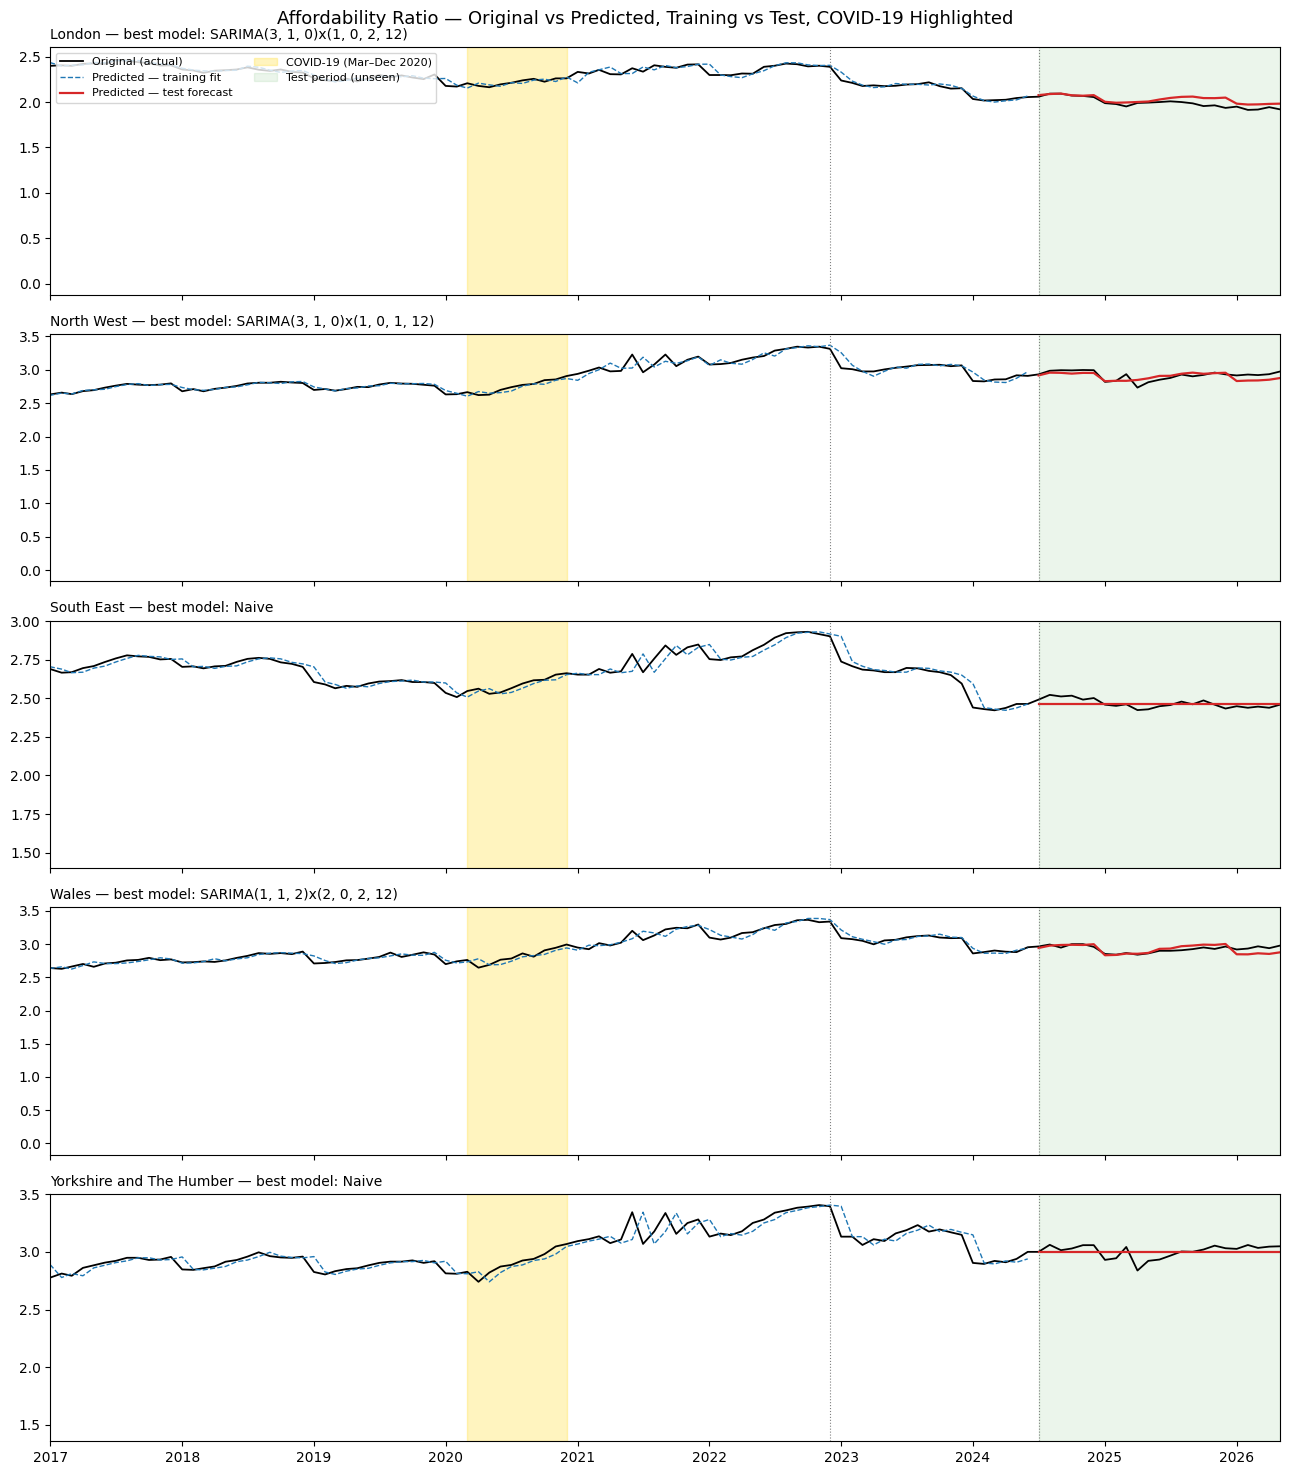

In [46]:
# Plot: Original vs Predicted, Train vs Test, COVID window highlighted — Affordability Ratio target

fig, axes = plt.subplots(len(regions), 1, figsize=(13, 3 * len(regions)), sharex=True)

for ax, region in zip(axes, regions):
    d = covid_fig_data[(region, 'AffordabilityRatio')]
    ax.plot(d['actual'].index, d['actual'].values, color='black', lw=1.3, label='Original (actual)')
    ax.plot(d['fitted'].index, d['fitted'].values, color='tab:blue', lw=1, ls='--', label='Predicted — training fit')
    ax.plot(d['forecast'].index, d['forecast'].values, color='tab:red', lw=1.6, label='Predicted — test forecast')

    ax.axvspan(covid_start, covid_end, color='gold', alpha=0.25, label='COVID-19 (Mar–Dec 2020)')
    ax.axvspan(test_start_ts, d['actual'].index.max(), color='green', alpha=0.08, label='Test period (unseen)')
    ax.axvline(train_end_ts, color='grey', lw=0.8, ls=':')
    ax.axvline(test_start_ts, color='grey', lw=0.8, ls=':')

    ax.set_title(f"{region} — best model: {d['model']}", fontsize=10, loc='left')
    ax.set_xlim(pd.Timestamp('2017-01-01'), d['actual'].index.max())

axes[0].legend(loc='upper left', fontsize=8, ncol=2)
fig.suptitle('Affordability Ratio — Original vs Predicted, Training vs Test, COVID-19 Highlighted', fontsize=13)
plt.tight_layout()
plt.savefig('chart_covid_affordability_original_vs_predicted.png', dpi=150)
plt.show()

## 10b. Chart 5 — Regional Affordability Deterioration

                  Region  Affordability_2000  Affordability_2026  Pct_Change
              North West            1.410737            2.973689  110.789719
                   Wales            1.462960            2.977986  103.559012
Yorkshire and The Humber            1.502600            3.049156  102.925419
                  London            1.111387            1.919826   72.741530
              South East            1.500600            2.458545   63.837431


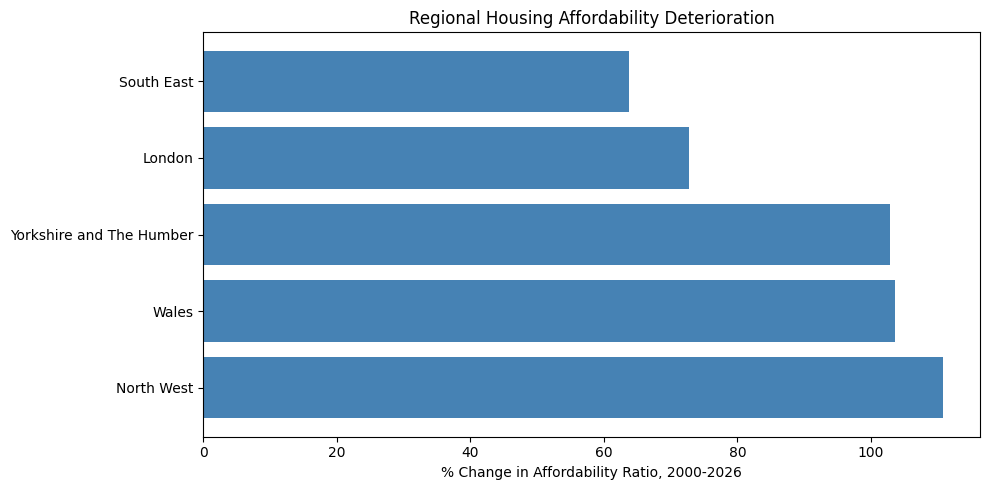

In [47]:
afford_summary = df.groupby('Region').agg(
    Affordability_2000=('AffordabilityRatio', lambda x: x.iloc[0]),
    Affordability_2026=('AffordabilityRatio', lambda x: x.iloc[-1]),
).reset_index()
afford_summary['Pct_Change'] = ((afford_summary['Affordability_2026'] - afford_summary['Affordability_2000'])
                                  / afford_summary['Affordability_2000'] * 100)
afford_summary = afford_summary.sort_values('Pct_Change', ascending=False)
afford_summary.to_csv('regional_affordability_change.csv', index=False)
print(afford_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(afford_summary['Region'], afford_summary['Pct_Change'], color='steelblue')
ax.set_xlabel('% Change in Affordability Ratio, 2000-2026')
ax.set_title('Regional Housing Affordability Deterioration')
plt.tight_layout()
plt.savefig('chart5_regional_affordability_change.png', dpi=150)
plt.show()

## 10c. Chart 6 — Forecast Difficulty by Region

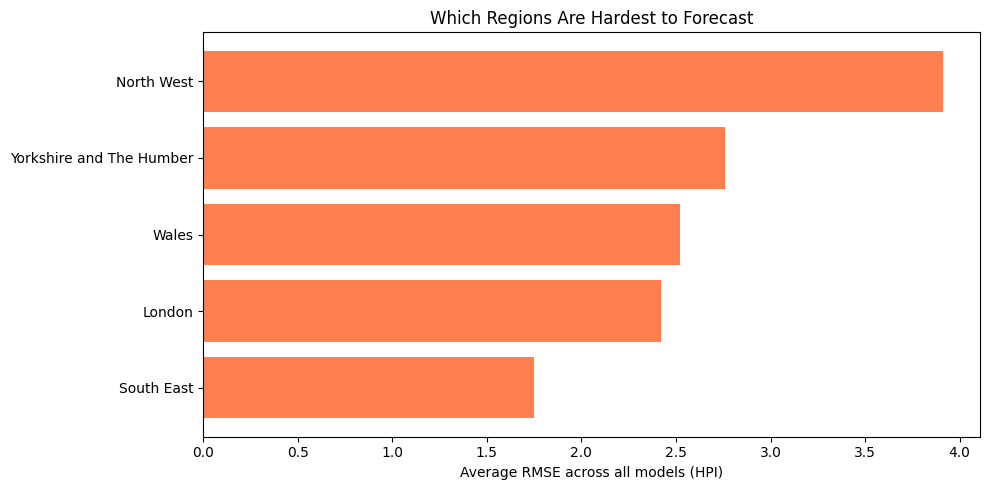

In [48]:
region_avg_rmse = combined[combined['Target']=='HPI'].groupby('Region')['RMSE'].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(region_avg_rmse.index, region_avg_rmse.values, color='coral')
ax.set_xlabel('Average RMSE across all models (HPI)')
ax.set_title('Which Regions Are Hardest to Forecast')
plt.tight_layout()
plt.savefig('chart6_region_forecast_difficulty.png', dpi=150)
plt.show()